# 12 — BCHH rotation, polarization, and direct-seismic-wave search

This notebook rotates the canonical BCHH three-component seismogram to Z/N/E and source-relative Z/R/T coordinates, computes covariance and TwistPy polarization attributes, and searches for weak direct seismic arrivals before the much stronger ground-coupled airwaves.

The analysis is intentionally exploratory. Candidate P-wave picks are retained as provisional measurements with uncertainties, not treated as automatic phase identifications. The most repeatable result is a travel time of approximately **1.1 s** after both the second-stage source event and the capsule impact/explosion.


## 1. Imports, project paths, and authoritative inputs


In [17]:
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from obspy.signal.rotate import rotate_ne_rt

try:
    from flovopy.processing.spectrograms import icewebSpectrogram
except ImportError as exc:
    raise ImportError(
        "This notebook requires FLOVOpy spectrogram support: "
        "from flovopy.processing.spectrograms import icewebSpectrogram"
    ) from exc

try:
    from twistpy.polarization import TimeDomainAnalysis3C
except ImportError as exc:
    raise ImportError(
        "TwistPy is required for Notebook 12. Install it in this kernel with "
        "`python -m pip install twistpy`."
    ) from exc

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Run 02_prepare_analysis_inputs.ipynb first: {ANALYSIS_CONFIG_FILE}"
    )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

SOURCE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()

for label, path in {
    "corrected waveform Stream": SOURCE_STREAM_FILE,
    "calibrated StationXML": STATIONXML_FILE,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

OUTPUT_ROOT = config.OUTPUT_DIR / "12_polarization"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POLARIZATION_CSV = OUTPUT_ROOT / "12_polarization_timeseries.csv"
POLARIZATION_NPZ = OUTPUT_ROOT / "12_polarization_timeseries.npz"
ROTATED_ZNE_PICKLE = OUTPUT_ROOT / "12_seismic_zne.pkl"
ROTATED_ZRT_PICKLE = OUTPUT_ROOT / "12_seismic_zrt.pkl"
SUMMARY_JSON = OUTPUT_ROOT / "12_polarization_summary.json"
DIAGNOSTIC_FIGURE = config.FIGURE_DIR / "12_polarization_diagnostics.png"
TWISTPY_ZNE_FIGURE = config.FIGURE_DIR / "12_twistpy_style_zne.png"
TWISTPY_ZRT_FIGURE = config.FIGURE_DIR / "12_twistpy_style_zrt.png"
MULTIBAND_OUTPUT_DIR = OUTPUT_ROOT / "multiband"
MULTIBAND_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MULTIBAND_TABLE = MULTIBAND_OUTPUT_DIR / "12_multiband_polarization_timeseries.csv"
MULTIBAND_COMPARISON_FIGURE = config.FIGURE_DIR / "12_multiband_polarization_comparison.png"
SPECTROGRAM_FIGURES = []

print("Waveform source:", SOURCE_STREAM_FILE)
print("StationXML:", STATIONXML_FILE)
print("Output directory:", OUTPUT_ROOT)


Waveform source: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.pkl
StationXML: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/01_BCHH_20160901_empirically_calibrated.xml
Output directory: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization


## 2. Analysis controls


In [18]:
# -----------------------------------------------------------------------------
# Common event interval
# -----------------------------------------------------------------------------
# The source-time picks are copied from 12_generate_paper_figures_best.ipynb so
# the polarization and waveform/spectrogram figures use the same chronology.
SECOND_STAGE_SOURCE_TIME = UTCDateTime("2016-09-01T13:07:12.080")
PRECURSOR1_SOURCE_TIME = UTCDateTime("2016-09-01T13:07:15.283")
PRECURSOR2_SOURCE_TIME = UTCDateTime("2016-09-01T13:07:15.517")
FIRST_STAGE_SOURCE_TIME = UTCDateTime("2016-09-01T13:07:15.750")
CAPSULE_SOURCE_TIME = UTCDateTime("2016-09-01T13:07:24.600")

SOURCE_EVENTS = {
    "Second stage": SECOND_STAGE_SOURCE_TIME,
    #"Precursor 1": PRECURSOR1_SOURCE_TIME,
    #"Precursor 2": PRECURSOR2_SOURCE_TIME,
    "First stage": FIRST_STAGE_SOURCE_TIME,
    "Capsule": CAPSULE_SOURCE_TIME,
}

# One common interval is preferable because the events are separated by only a
# few seconds. It includes several seconds of pre-event noise and extends beyond
# the capsule source time and its expected acoustic arrival.
PLOT_START = SECOND_STAGE_SOURCE_TIME - 7.0
PLOT_END = CAPSULE_SOURCE_TIME + 7.0

# -----------------------------------------------------------------------------
# Frequency bands
# -----------------------------------------------------------------------------
# These are exploratory bands, not prior classifications. The 3–10 Hz band is
# expected to emphasize the ground-coupled airwave. Higher bands are included to
# search for short, direct seismic onsets that could be obscured at lower
# frequencies. Bands are clipped below Nyquist later in the notebook.
POLARIZATION_BANDS_HZ = {
    "broad_0p5_20": (0.5, 20.0),
    "low_0p5_3": (0.5, 3.0),
    "airwave_3_10": (3.0, 10.0),
    "high_10_25": (10.0, 25.0),
    "very_high_25_45": (25.0, 45.0),
}

# Default single-band products retained for Notebook 13 compatibility.
FILTER_FREQMIN_HZ = 0.5
FILTER_FREQMAX_HZ = 20.0
FILTER_CORNERS = 4
FILTER_ZEROPHASE = True

# Shorter windows give better onset timing; longer windows give more stable
# ellipse estimates. The focused band comparison below can override this per band.
WINDOW_LENGTH_S = 0.40
WINDOW_OVERLAP = 0.90
BAND_WINDOW_LENGTH_S = {
    "broad_0p5_20": 0.50,
    "low_0p5_3": 1.00,
    "airwave_3_10": 0.50,
    "high_10_25": 0.25,
    "very_high_25_45": 0.20,
}

# Predicted acoustic arrival marker. This should remain distinct from any manual
# trace/video timing adjustment used elsewhere. Use the physically modeled value
# here and revise only in one place if the authoritative value changes.
ACOUSTIC_TRAVEL_TIME_S = 4.040

# Search windows after each source time in which a direct seismic onset might
# occur before the acoustic arrival. These are visualization aids, not picks.
DIRECT_SEISMIC_SEARCH_MIN_S = 0.0
DIRECT_SEISMIC_SEARCH_MAX_S = 2.0

# Figure controls.
NORMALIZE_COMPONENTS = True
WAVEFORM_LINEWIDTH = 0.8
POLARIZATION_MARKER_SIZE = 8
SHOW_LOW_DOP = True
DOP_DISPLAY_THRESHOLD = 0.0
EVENT_MARKER_ALPHA = 0.85

# Spectrogram controls. A 0.40-s FFT gives ~2.5-Hz true resolution before zero
# padding but preserves timing of closely spaced pulses. Also generate a 1.0-s
# version for comparison when frequency resolution is more important.
SPECTROGRAM_FFT_WINDOWS_S = (0.40, 1.00)
SPECTROGRAM_FMIN_HZ = 0.5
SPECTROGRAM_FMAX_HZ = 45.0
SPECTROGRAM_DYNAMIC_RANGE_DB = 70.0

# Leave None to analyze the complete canonical Notebook 02 time window.
ANALYSIS_START = None
ANALYSIS_END = None


# -----------------------------------------------------------------------------
# Focused event figures and provisional direct-P picks
# -----------------------------------------------------------------------------
# Each event-centered figure uses the same plotting function. Independent
# component scales help reveal weak onsets; common Z/R/T scales preserve true
# component-amplitude relationships.
EVENT_ZOOMS = {
    "second_stage": {
        "label": "second-stage source event",
        "time": SECOND_STAGE_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
    "capsule": {
        "label": "capsule impact/explosion",
        "time": CAPSULE_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
    "main_explosion": {
        "label": "main explosion",
        "time": FIRST_STAGE_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
}

# Provisional manual picks inferred from waveform and polarization changes.
# The main-explosion interval is strongly contaminated by the earlier event's
# acoustic arrival, so no preferred P pick is adopted for it here.
PROVISIONAL_P_PICKS = {
    "second_stage": {"travel_time_s": 1.1, "uncertainty_s": 0.2},
    "capsule": {"travel_time_s": 1.1, "uncertainty_s": 0.3},
}

if not (0.0 <= WINDOW_OVERLAP < 1.0):
    raise ValueError("WINDOW_OVERLAP must be in [0, 1).")
if PLOT_END <= PLOT_START:
    raise ValueError("PLOT_END must be later than PLOT_START.")
if not (0.0 <= DOP_DISPLAY_THRESHOLD <= 1.0):
    raise ValueError("DOP_DISPLAY_THRESHOLD must be in [0, 1].")


## 3. Load, isolate, and rotate the three-component seismogram


In [19]:
st_all = read(str(SOURCE_STREAM_FILE), format="PICKLE")
inventory = read_inventory(str(STATIONXML_FILE))


def utc_epoch_seconds(value) -> float:
    """Return epoch seconds for ObsPy UTCDateTime or datetime-like values."""
    if isinstance(value, UTCDateTime):
        return float(value.timestamp)
    timestamp = getattr(value, "timestamp", None)
    if callable(timestamp):
        return float(timestamp())
    if timestamp is not None:
        return float(timestamp)
    return float(UTCDateTime(value).timestamp)


def unique_component(stream: Stream, component: str) -> Trace:
    """Return exactly one trace whose channel code ends with component."""
    component = component.upper()
    matches = [
        trace for trace in stream
        if str(trace.stats.channel).upper().endswith(component)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {component} component; "
            f"found {[trace.id for trace in matches]}"
        )
    return matches[0]


def assert_sample_aligned(
    traces: tuple[Trace, ...],
    *,
    labels: tuple[str, ...] = ("Z", "N", "E"),
) -> None:
    """Validate that traces share one sampling grid without hashing UTCDateTime."""
    if len(traces) != len(labels):
        raise ValueError("traces and labels must have the same length")

    sampling_rates = np.asarray(
        [float(trace.stats.sampling_rate) for trace in traces],
        dtype=float,
    )
    npts = np.asarray([int(trace.stats.npts) for trace in traces], dtype=int)
    starttimes = [trace.stats.starttime for trace in traces]
    endtimes = [trace.stats.endtime for trace in traces]

    reference_start = starttimes[0]
    start_offsets_s = np.asarray(
        [float(starttime - reference_start) for starttime in starttimes],
        dtype=float,
    )

    reference_end = endtimes[0]
    end_offsets_s = np.asarray(
        [float(endtime - reference_end) for endtime in endtimes],
        dtype=float,
    )

    sampling_rate_ok = np.allclose(
        sampling_rates,
        sampling_rates[0],
        rtol=0.0,
        atol=1e-9,
    )
    npts_ok = bool(np.all(npts == npts[0]))

    # UTCDateTime subtraction is robust here and avoids placing UTCDateTime
    # objects in sets, which fails with some ObsPy versions.
    time_tolerance_s = max(1e-9, 1e-6 / sampling_rates[0])
    starts_ok = np.allclose(
        start_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )
    ends_ok = np.allclose(
        end_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )

    if not (sampling_rate_ok and npts_ok and starts_ok and ends_ok):
        details = "\n".join(
            f"  {label}: id={trace.id}, sr={trace.stats.sampling_rate}, "
            f"npts={trace.stats.npts}, start={trace.stats.starttime}, "
            f"end={trace.stats.endtime}, "
            f"start_offset_s={start_offset:.12g}, "
            f"end_offset_s={end_offset:.12g}"
            for label, trace, start_offset, end_offset in zip(
                labels, traces, start_offsets_s, end_offsets_s
            )
        )
        raise ValueError(
            "Z/N/E traces are not sample-aligned after common-window trimming.\n"
            f"{details}"
        )


seismic_channels = tuple(
    str(channel).upper() for channel in analysis_config["seismic_channels"]
)
st_seismic = Stream([
    trace.copy()
    for trace in st_all
    if str(trace.stats.channel).upper() in seismic_channels
])

if len(st_seismic) != 3:
    raise ValueError(
        "Expected exactly three canonical seismic components from Notebook 02; "
        f"requested channels={list(seismic_channels)}, "
        f"found={[trace.id for trace in st_seismic]}"
    )

if ANALYSIS_START is not None or ANALYSIS_END is not None:
    requested_start = (
        UTCDateTime(ANALYSIS_START)
        if ANALYSIS_START is not None
        else min(trace.stats.starttime for trace in st_seismic)
    )
    requested_end = (
        UTCDateTime(ANALYSIS_END)
        if ANALYSIS_END is not None
        else max(trace.stats.endtime for trace in st_seismic)
    )
    if requested_end <= requested_start:
        raise ValueError(
            f"ANALYSIS_END must be after ANALYSIS_START: "
            f"{requested_start} to {requested_end}"
        )
    st_seismic.trim(requested_start, requested_end, pad=False)

# First use the channels exactly as stored when they are already Z/N/E.
# Otherwise rotate the three recorded sensor axes to geographic Z/N/E using
# the event-epoch StationXML orientation metadata produced by Notebook 01.
components_before_rotation = {
    str(trace.stats.channel)[-1].upper() for trace in st_seismic
}
if components_before_rotation == {"Z", "N", "E"}:
    st_zne = st_seismic.copy()
    rotation_method = "input channels already Z/N/E"
else:
    st_zne = st_seismic.copy()
    try:
        st_zne.rotate(method="->ZNE", inventory=inventory)
    except Exception as exc:
        raise RuntimeError(
            "ObsPy could not rotate the canonical seismic channels to Z/N/E. "
            f"Input traces were {[trace.id for trace in st_seismic]}. "
            "Check that the event-epoch StationXML contains azimuth and dip "
            "for all three channels."
        ) from exc
    rotation_method = "ObsPy ->ZNE using calibrated StationXML"

# Merge segments component-by-component, then retain only the common time
# interval. Interpolation is used only to fill internal gaps during merging;
# no padding is added beyond the observed common interval.
st_zne.merge(method=1, fill_value="interpolate")
if len(st_zne) != 3:
    raise ValueError(
        "Expected exactly three traces after Z/N/E rotation and merging; "
        f"found {[trace.id for trace in st_zne]}"
    )

common_start = max(trace.stats.starttime for trace in st_zne)
common_end = min(trace.stats.endtime for trace in st_zne)
if common_end <= common_start:
    raise ValueError(
        "The rotated Z/N/E components have no common time interval: "
        f"common_start={common_start}, common_end={common_end}"
    )

st_zne.trim(common_start, common_end, pad=False, nearest_sample=True)
st_zne.sort(keys=["channel"])

tr_z = unique_component(st_zne, "Z")
tr_n = unique_component(st_zne, "N")
tr_e = unique_component(st_zne, "E")
assert_sample_aligned((tr_z, tr_n, tr_e))

back_azimuth_deg = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
if not np.isfinite(back_azimuth_deg):
    raise ValueError(
        "Notebook 02 supplied a non-finite SLC-40 back-azimuth: "
        f"{back_azimuth_deg}"
    )

r_data, t_data = rotate_ne_rt(
    np.asarray(tr_n.data, dtype=np.float64),
    np.asarray(tr_e.data, dtype=np.float64),
    back_azimuth_deg,
)

tr_r = tr_n.copy()
tr_r.data = np.asarray(r_data, dtype=np.float64)
tr_r.stats.channel = str(tr_r.stats.channel)[:-1] + "R"
tr_r.stats.processing = list(getattr(tr_r.stats, "processing", []))
tr_r.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

tr_t = tr_e.copy()
tr_t.data = np.asarray(t_data, dtype=np.float64)
tr_t.stats.channel = str(tr_t.stats.channel)[:-1] + "T"
tr_t.stats.processing = list(getattr(tr_t.stats, "processing", []))
tr_t.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

st_zrt = Stream([tr_z.copy(), tr_r, tr_t])
assert_sample_aligned(tuple(st_zrt), labels=("Z", "R", "T"))

# Use ObsPy's PICKLE writer so these products can be read consistently with
# read(..., format="PICKLE") in Notebook 13.
st_zne.write(str(ROTATED_ZNE_PICKLE), format="PICKLE")
st_zrt.write(str(ROTATED_ZRT_PICKLE), format="PICKLE")

print("Input seismic channels:", [trace.id for trace in st_seismic])
print("Rotation to ZNE:", rotation_method)
print("ZNE:", [trace.id for trace in st_zne])
print("ZRT:", [trace.id for trace in st_zrt])
print(
    "Common interval:",
    tr_z.stats.starttime,
    "to",
    tr_z.stats.endtime,
    f"({tr_z.stats.npts} samples at {tr_z.stats.sampling_rate:g} Hz)",
)
print(f"SLC-40 back-azimuth: {back_azimuth_deg:.3f}°")


Input seismic channels: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
Rotation to ZNE: input channels already Z/N/E
ZNE: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
ZRT: ['1R.BCHH.10.DHZ', '1R.BCHH.10.DHR', '1R.BCHH.10.DHT']
Common interval: 2016-09-01T13:04:12.080000Z to 2016-09-01T13:37:12.080000Z (495001 samples at 250 Hz)
SLC-40 back-azimuth: 199.438°


## 4. Prepare the filtered analysis traces


In [20]:
def prepare_analysis_stream(stream: Stream) -> Stream:
    """Return a consistently detrended, tapered, and filtered copy."""
    out = stream.copy()
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.02, type="cosine")
    out.filter(
        "bandpass",
        freqmin=FILTER_FREQMIN_HZ,
        freqmax=FILTER_FREQMAX_HZ,
        corners=FILTER_CORNERS,
        zerophase=FILTER_ZEROPHASE,
    )
    return out


# TwistPy uses geographic N/E/Z. The rotated stream is retained separately for
# source-relative waveform display and radial/transverse measurements.
st_analysis_zne = prepare_analysis_stream(st_zne)
st_analysis_zrt = prepare_analysis_stream(st_zrt)

z = unique_component(st_analysis_zne, "Z")
n = unique_component(st_analysis_zne, "N")
e = unique_component(st_analysis_zne, "E")

z_rt = unique_component(st_analysis_zrt, "Z")
r = unique_component(st_analysis_zrt, "R")
t = unique_component(st_analysis_zrt, "T")

assert_sample_aligned((z, n, e), labels=("Z", "N", "E"))
assert_sample_aligned((z_rt, r, t), labels=("Z", "R", "T"))

print("Filtered ZNE stream:")
print(st_analysis_zne)
print("\nFiltered ZRT stream:")
print(st_analysis_zrt)


Filtered ZNE stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples

Filtered ZRT stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


## 5. Covariance linearity, rectilinearity, and planarity


In [21]:
def covariance_polarization(
    z_values: np.ndarray,
    n_values: np.ndarray,
    e_values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_length_s: float,
    overlap: float,
):
    """Sliding real-covariance polarization in [Z, N, E] coordinates."""
    x = np.column_stack([
        np.asarray(z_values, dtype=float),
        np.asarray(n_values, dtype=float),
        np.asarray(e_values, dtype=float),
    ])
    nwin = max(3, int(round(window_length_s * sampling_rate_hz)))
    nstep = max(1, int(round(nwin * (1.0 - overlap))))

    rows = []
    for i0 in range(0, len(x) - nwin + 1, nstep):
        xx = x[i0:i0 + nwin]
        finite = np.isfinite(xx).all(axis=1)
        xx = xx[finite]
        center_sample = i0 + 0.5 * (nwin - 1)

        if len(xx) < 3:
            rows.append((center_sample, *([np.nan] * 8)))
            continue

        xx = xx - xx.mean(axis=0, keepdims=True)
        covariance = np.cov(xx, rowvar=False, bias=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = np.maximum(eigenvalues[order], 0.0)
        eigenvectors = eigenvectors[:, order]
        lambda1, lambda2, lambda3 = eigenvalues

        # The waveform units are velocity, so valid covariance eigenvalues can
        # be far below machine epsilon in absolute magnitude (e.g. 1e-24).
        # Machine epsilon is a relative precision measure, not a physical
        # amplitude threshold. Only reject non-finite or genuinely zero energy.
        if not np.isfinite(lambda1) or lambda1 <= np.finfo(float).tiny:
            linearity = rectilinearity = planarity = np.nan
            azimuth_deg = incidence_deg = np.nan
        else:
            linearity = (lambda1 - lambda2) / lambda1
            rectilinearity = 1.0 - (lambda2 + lambda3) / (2.0 * lambda1)
            planarity = (lambda2 - lambda3) / lambda1

            vz, vn, ve = eigenvectors[:, 0]
            if vz < 0:
                vz, vn, ve = -vz, -vn, -ve
            incidence_deg = np.degrees(np.arctan2(np.hypot(vn, ve), abs(vz)))
            azimuth_deg = np.degrees(np.arctan2(ve, vn)) % 180.0

        rows.append((
            center_sample,
            linearity,
            rectilinearity,
            planarity,
            azimuth_deg,
            incidence_deg,
            lambda1,
            lambda2,
            lambda3,
        ))

    columns = [
        "center_sample", "linearity", "rectilinearity", "planarity",
        "covariance_azimuth_deg", "covariance_incidence_deg",
        "lambda1", "lambda2", "lambda3",
    ]
    return pd.DataFrame(rows, columns=columns), nwin, nstep


sampling_rate_hz = float(z.stats.sampling_rate)
covariance_df, covariance_nwin, covariance_nstep = covariance_polarization(
    z.data,
    n.data,
    e.data,
    sampling_rate_hz=sampling_rate_hz,
    window_length_s=WINDOW_LENGTH_S,
    overlap=WINDOW_OVERLAP,
)

covariance_df["time_epoch_s"] = (
    utc_epoch_seconds(z.stats.starttime)
    + covariance_df["center_sample"] / sampling_rate_hz
)
covariance_df["time_utc"] = covariance_df["time_epoch_s"].map(
    lambda value: str(UTCDateTime(value))
)
covariance_df["elapsed_from_explosion_s"] = (
    covariance_df["time_epoch_s"] - utc_epoch_seconds(config.EXPLOSION_TIME)
)

display(covariance_df.head())


,center_sample,linearity,rectilinearity,planarity,covariance_azimuth_deg,covariance_incidence_deg,lambda1,lambda2,lambda3,time_epoch_s,time_utc,elapsed_from_explosion_s
0,49.5,0.995374,0.997602,0.004456,24.044910,71.556221,8.487397e-25,3.926419e-27,1.443191e-28,1.472735e+09,2016-09-01T13:04:12.278000Z,-179.802
1,59.5,0.996657,0.998250,0.003185,21.415341,72.215265,1.048701e-24,3.505673e-27,1.655963e-28,1.472735e+09,2016-09-01T13:04:12.318000Z,-179.762
2,69.5,0.996615,0.998181,0.003131,18.794392,73.233184,1.245407e-24,4.215201e-27,3.160254e-28,1.472735e+09,2016-09-01T13:04:12.358000Z,-179.722
3,79.5,0.997252,0.998467,0.002428,16.938541,74.442556,1.438170e-24,3.951695e-27,4.591599e-28,1.472735e+09,2016-09-01T13:04:12.398000Z,-179.682
4,89.5,0.997872,0.998715,0.001687,15.390689,75.479695,1.652088e-24,3.516358e-27,7.291787e-28,1.472735e+09,2016-09-01T13:04:12.438000Z,-179.642


## 6. TwistPy complex-signal ellipticity


In [22]:
analysis = TimeDomainAnalysis3C(
    N=n,
    E=e,
    Z=z,
    window={
        "window_length_seconds": float(WINDOW_LENGTH_S),
        "overlap": float(WINDOW_OVERLAP),
    },
    timeaxis="rel",
)
analysis.polarization_analysis()

# TwistPy's ``timeaxis="utc"`` returns Matplotlib serial-day values, not
# Unix epoch seconds. Using those values as epoch seconds places the results
# near 1970 and causes every event-window plot to be empty. Use the relative
# time axis and anchor it explicitly to the waveform start time.
twistpy_relative_s = np.asarray(analysis.t_windows, dtype=float)
twistpy_epoch_s = (
    utc_epoch_seconds(z.stats.starttime)
    + twistpy_relative_s
)

if len(twistpy_epoch_s) == 0:
    raise RuntimeError("TwistPy returned no polarization windows.")
if not np.all(np.isfinite(twistpy_epoch_s)):
    raise RuntimeError("TwistPy returned non-finite polarization times.")

major_azimuth_deg = np.asarray(analysis.azi1, dtype=float)
minor_azimuth_deg = np.asarray(analysis.azi2, dtype=float)

# Fold source-relative azimuth to [0, 180):
#   0/180 = radial plane; 90 = transverse direction.
major_source_relative_deg = (major_azimuth_deg - back_azimuth_deg) % 180.0
minor_source_relative_deg = (minor_azimuth_deg - back_azimuth_deg) % 180.0

twistpy_df = pd.DataFrame({
    "time_epoch_s": twistpy_epoch_s,
    "time_utc": [str(UTCDateTime(value)) for value in twistpy_epoch_s],
    "elapsed_from_explosion_s": twistpy_epoch_s - utc_epoch_seconds(config.EXPLOSION_TIME),
    "ellipticity": np.asarray(analysis.elli, dtype=float),
    "degree_of_polarization": np.asarray(analysis.dop, dtype=float),
    "twistpy_major_azimuth_deg": major_azimuth_deg,
    "twistpy_minor_azimuth_deg": minor_azimuth_deg,
    "twistpy_major_source_relative_azimuth_deg": major_source_relative_deg,
    "twistpy_minor_source_relative_azimuth_deg": minor_source_relative_deg,
    "twistpy_major_inclination_deg": np.asarray(analysis.inc1, dtype=float),
    "twistpy_minor_inclination_deg": np.asarray(analysis.inc2, dtype=float),
})

display(twistpy_df.head())
print("Covariance windows:", len(covariance_df))
print("TwistPy windows:", len(twistpy_df))
print(
    "TwistPy UTC range:",
    UTCDateTime(twistpy_epoch_s[0]),
    "to",
    UTCDateTime(twistpy_epoch_s[-1]),
)
print(
    "TwistPy elapsed range relative to explosion:",
    f"{twistpy_df['elapsed_from_explosion_s'].iloc[0]:.3f}",
    "to",
    f"{twistpy_df['elapsed_from_explosion_s'].iloc[-1]:.3f}",
    "s",
)


Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


,time_epoch_s,time_utc,elapsed_from_explosion_s,ellipticity,degree_of_polarization,twistpy_major_azimuth_deg,twistpy_minor_azimuth_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_inclination_deg
0,1.472735e+09,2016-09-01T13:04:12.280000Z,-179.800,0.319975,0.936071,8.226199,101.767841,168.788172,82.329814,75.922161,76.161528
1,1.472735e+09,2016-09-01T13:04:12.316000Z,-179.764,0.342375,0.977681,9.580683,103.578666,170.142657,84.140640,75.710717,74.690796
2,1.472735e+09,2016-09-01T13:04:12.352000Z,-179.728,0.346853,0.989113,10.812263,104.985466,171.374236,85.547439,75.476829,74.308951
3,1.472735e+09,2016-09-01T13:04:12.388000Z,-179.692,0.344571,0.993287,11.873707,105.998079,172.435681,86.560053,75.328760,74.639142
4,1.472735e+09,2016-09-01T13:04:12.424000Z,-179.656,0.340451,0.994908,12.775242,106.699171,173.337216,87.261145,75.244971,75.434902


Covariance windows: 49491
TwistPy windows: 54989
TwistPy UTC range: 2016-09-01T13:04:12.280000Z to 2016-09-01T13:37:11.848000Z
TwistPy elapsed range relative to explosion: -179.800 to 1799.768 s


## 7. Merge and write the canonical polarization products


In [23]:
# The implementations can differ by a fraction of a sample in their window
# centers. Merge each covariance result onto the nearest TwistPy window with a
# tolerance of one covariance step.
merge_tolerance_s = max(
    covariance_nstep / sampling_rate_hz,
    1.0 / sampling_rate_hz,
)

polarization = pd.merge_asof(
    twistpy_df.sort_values("time_epoch_s"),
    covariance_df.drop(columns=["time_utc", "elapsed_from_explosion_s"]).sort_values("time_epoch_s"),
    on="time_epoch_s",
    direction="nearest",
    tolerance=merge_tolerance_s,
)

preferred_order = [
    "time_utc", "time_epoch_s", "elapsed_from_explosion_s",
    "linearity", "rectilinearity", "planarity", "ellipticity",
    "degree_of_polarization",
    "covariance_azimuth_deg", "covariance_incidence_deg",
    "twistpy_major_azimuth_deg", "twistpy_major_inclination_deg",
    "twistpy_minor_azimuth_deg", "twistpy_minor_inclination_deg",
    "twistpy_major_source_relative_azimuth_deg",
    "twistpy_minor_source_relative_azimuth_deg",
    "lambda1", "lambda2", "lambda3", "center_sample",
]
polarization = polarization[[
    column for column in preferred_order if column in polarization.columns
]]

polarization.to_csv(POLARIZATION_CSV, index=False)
np.savez_compressed(
    POLARIZATION_NPZ,
    **{
        column: polarization[column].to_numpy()
        for column in polarization.columns
        if column != "time_utc"
    },
)

summary = {
    "producer_notebook": "12_rotate_and_compute_polarization.ipynb",
    "source_analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "source_waveform_stream": str(SOURCE_STREAM_FILE),
    "stationxml": str(STATIONXML_FILE),
    "seismic_channels": list(seismic_channels),
    "back_azimuth_to_slc40_deg": back_azimuth_deg,
    "zne_rotation_method": rotation_method,
    "common_start_utc": str(tr_z.stats.starttime),
    "common_end_utc": str(tr_z.stats.endtime),
    "sampling_rate_hz": float(tr_z.stats.sampling_rate),
    "npts": int(tr_z.stats.npts),
    "filter": {
        "type": "bandpass",
        "freqmin_hz": FILTER_FREQMIN_HZ,
        "freqmax_hz": FILTER_FREQMAX_HZ,
        "corners": FILTER_CORNERS,
        "zerophase": FILTER_ZEROPHASE,
    },
    "window_length_s": WINDOW_LENGTH_S,
    "window_overlap": WINDOW_OVERLAP,
    "covariance_step_s": covariance_nstep / sampling_rate_hz,
    "definitions": {
        "linearity": "(lambda1 - lambda2) / lambda1",
        "rectilinearity": "1 - (lambda2 + lambda3) / (2 lambda1)",
        "planarity": "(lambda2 - lambda3) / lambda1",
        "ellipticity": "TwistPy complex-signal polarization ellipse attribute",
        "source_relative_azimuth": "(geographic ellipse azimuth - SLC-40 back-azimuth) modulo 180 deg",
    },
    "outputs": {
        "polarization_csv": str(POLARIZATION_CSV),
        "polarization_npz": str(POLARIZATION_NPZ),
        "rotated_zne_pickle": str(ROTATED_ZNE_PICKLE),
        "rotated_zrt_pickle": str(ROTATED_ZRT_PICKLE),
        "diagnostic_figure": str(DIAGNOSTIC_FIGURE),
    },
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2) + "\n")

for path in (POLARIZATION_CSV, POLARIZATION_NPZ, ROTATED_ZNE_PICKLE, ROTATED_ZRT_PICKLE, SUMMARY_JSON):
    if not path.exists():
        raise FileNotFoundError(path)
    print(path)

display(polarization.head())


/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.csv
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.npz
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zne.pkl
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zrt.pkl
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_summary.json


,time_utc,time_epoch_s,elapsed_from_explosion_s,linearity,rectilinearity,planarity,ellipticity,degree_of_polarization,covariance_azimuth_deg,covariance_incidence_deg,twistpy_major_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_azimuth_deg,twistpy_minor_inclination_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,lambda1,lambda2,lambda3,center_sample
0,2016-09-01T13:04:12.280000Z,1.472735e+09,-179.800,0.995374,0.997602,0.004456,0.319975,0.936071,24.044910,71.556221,8.226199,75.922161,101.767841,76.161528,168.788172,82.329814,8.487397e-25,3.926419e-27,1.443191e-28,49.5
1,2016-09-01T13:04:12.316000Z,1.472735e+09,-179.764,0.996657,0.998250,0.003185,0.342375,0.977681,21.415341,72.215265,9.580683,75.710717,103.578666,74.690796,170.142657,84.140640,1.048701e-24,3.505673e-27,1.655963e-28,59.5
2,2016-09-01T13:04:12.352000Z,1.472735e+09,-179.728,0.996615,0.998181,0.003131,0.346853,0.989113,18.794392,73.233184,10.812263,75.476829,104.985466,74.308951,171.374236,85.547439,1.245407e-24,4.215201e-27,3.160254e-28,69.5
3,2016-09-01T13:04:12.388000Z,1.472735e+09,-179.692,0.997252,0.998467,0.002428,0.344571,0.993287,16.938541,74.442556,11.873707,75.328760,105.998079,74.639142,172.435681,86.560053,1.438170e-24,3.951695e-27,4.591599e-28,79.5
4,2016-09-01T13:04:12.424000Z,1.472735e+09,-179.656,0.997872,0.998715,0.001687,0.340451,0.994908,15.390689,75.479695,12.775242,75.244971,106.699171,75.434902,173.337216,87.261145,1.652088e-24,3.516358e-27,7.291787e-28,89.5


## 8. Diagnostic and TwistPy-style polarization figures


In [24]:
def normalized_data(trace: Trace) -> np.ndarray:
    """Normalize a trace by its largest absolute finite value."""
    values = np.asarray(trace.data, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return values
    scale = np.nanmax(np.abs(values[finite]))
    if not NORMALIZE_COMPONENTS or not np.isfinite(scale) or scale == 0.0:
        return values
    return values / scale


def subset_polarization(starttime: UTCDateTime, endtime: UTCDateTime) -> pd.DataFrame:
    start_epoch = utc_epoch_seconds(starttime)
    end_epoch = utc_epoch_seconds(endtime)
    out = polarization.loc[
        (polarization["time_epoch_s"] >= start_epoch)
        & (polarization["time_epoch_s"] <= end_epoch)
    ].copy()
    if out.empty:
        available_start = polarization["time_epoch_s"].min()
        available_end = polarization["time_epoch_s"].max()
        raise ValueError(
            "No polarization windows overlap the requested plot interval.\n"
            f"Requested: {starttime} to {endtime}\n"
            f"Available: {UTCDateTime(available_start)} to "
            f"{UTCDateTime(available_end)}\n"
            "This usually indicates an incorrect conversion of TwistPy's "
            "time axis."
        )

    out["plot_time_s"] = out["time_epoch_s"] - start_epoch
    if not SHOW_LOW_DOP or DOP_DISPLAY_THRESHOLD > 0.0:
        low_dop = out["degree_of_polarization"] < DOP_DISPLAY_THRESHOLD
        orientation_columns = [
            "twistpy_major_azimuth_deg",
            "twistpy_minor_azimuth_deg",
            "twistpy_major_source_relative_azimuth_deg",
            "twistpy_minor_source_relative_azimuth_deg",
            "twistpy_major_inclination_deg",
            "twistpy_minor_inclination_deg",
        ]
        out.loc[low_dop, orientation_columns] = np.nan
    return out


def plot_twistpy_style(
    stream: Stream,
    components: tuple[str, str, str],
    labels: tuple[str, str, str],
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    azimuth_mode: str,
    output_path: Path,
    title: str,
) -> None:
    """Create a five-panel figure modeled on the TwistPy example figure."""
    plot_stream = stream.copy().trim(starttime, endtime, pad=False)
    plot_pol = subset_polarization(starttime, endtime)
    print(
        f"{title}: plotting {len(plot_pol)} polarization windows "
        f"from {starttime} to {endtime}"
    )

    if azimuth_mode == "geographic":
        major_az_col = "twistpy_major_azimuth_deg"
        minor_az_col = "twistpy_minor_azimuth_deg"
        az_title = "Azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from north"
    elif azimuth_mode == "source_relative":
        major_az_col = "twistpy_major_source_relative_azimuth_deg"
        minor_az_col = "twistpy_minor_source_relative_azimuth_deg"
        az_title = "Source-relative azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from radial"
    else:
        raise ValueError(f"Unsupported azimuth_mode: {azimuth_mode}")

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 11), sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 1.0, 1.0]},
        constrained_layout=True,
    )

    # Top panel: all three components, normalized as in the supplied example.
    line_styles = (":", "--", "-")
    for component, label, linestyle in zip(components, labels, line_styles):
        trace = unique_component(plot_stream, component)
        time_s = trace.times(reftime=starttime)
        axes[0].plot(
            time_s,
            normalized_data(trace),
            linestyle=linestyle,
            color="black",
            lw=WAVEFORM_LINEWIDTH,
            label=label,
        )
    axes[0].set_ylabel("Normalized amplitude" if NORMALIZE_COMPONENTS else "Amplitude")
    axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    axes[0].set_title("Three-component waveforms")

    # TwistPy-style scatter panels.
    axes[1].scatter(
        plot_pol["plot_time_s"], plot_pol["ellipticity"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Ellipticity")
    axes[1].set_title("Ellipticity")

    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_major_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_minor_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[2].set_ylim(-2, 92)
    axes[2].set_yticks([0, 30, 60, 90])
    axes[2].set_ylabel("Degrees")
    axes[2].set_title("Inclination of major and minor semi-axis")
    axes[2].legend(loc="lower right")

    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[major_az_col],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[minor_az_col],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[3].set_ylim(-5, 185)
    axes[3].set_yticks([0, 45, 90, 135, 180])
    axes[3].set_ylabel(az_ylabel)
    axes[3].set_title(az_title)
    axes[3].legend(loc="upper left")

    axes[4].scatter(
        plot_pol["plot_time_s"], plot_pol["degree_of_polarization"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("DOP")
    axes[4].set_title("Degree of polarization")
    axes[4].set_xlabel(
        f"Time since {starttime.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]} UTC (s)"
    )

    for ax in axes:
        ax.set_xlim(0.0, float(endtime - starttime))
        ax.grid(False)

    fig.suptitle(
        f"{title}\n"
        f"{FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
        f"{WINDOW_LENGTH_S:g} s window; {WINDOW_OVERLAP:.0%} overlap"
    )
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

BCHH TwistPy polarization — geographic Z/N/E: plotting 737 polarization windows from 2016-09-01T13:07:05.080000Z to 2016-09-01T13:07:31.600000Z


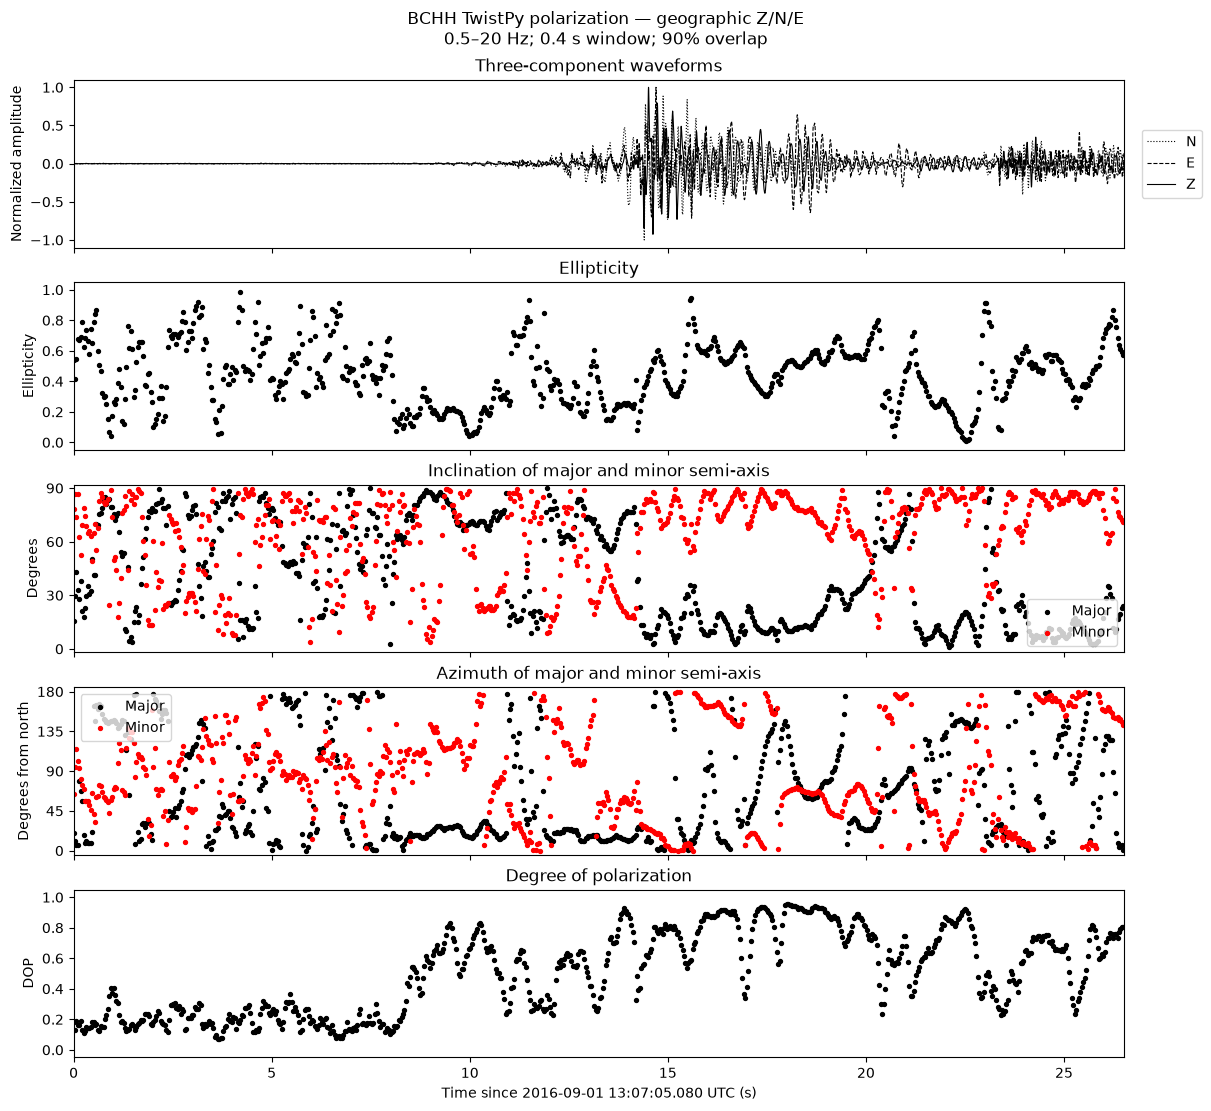

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_style_zne.png
BCHH TwistPy polarization — source-relative Z/R/T: plotting 737 polarization windows from 2016-09-01T13:07:05.080000Z to 2016-09-01T13:07:31.600000Z


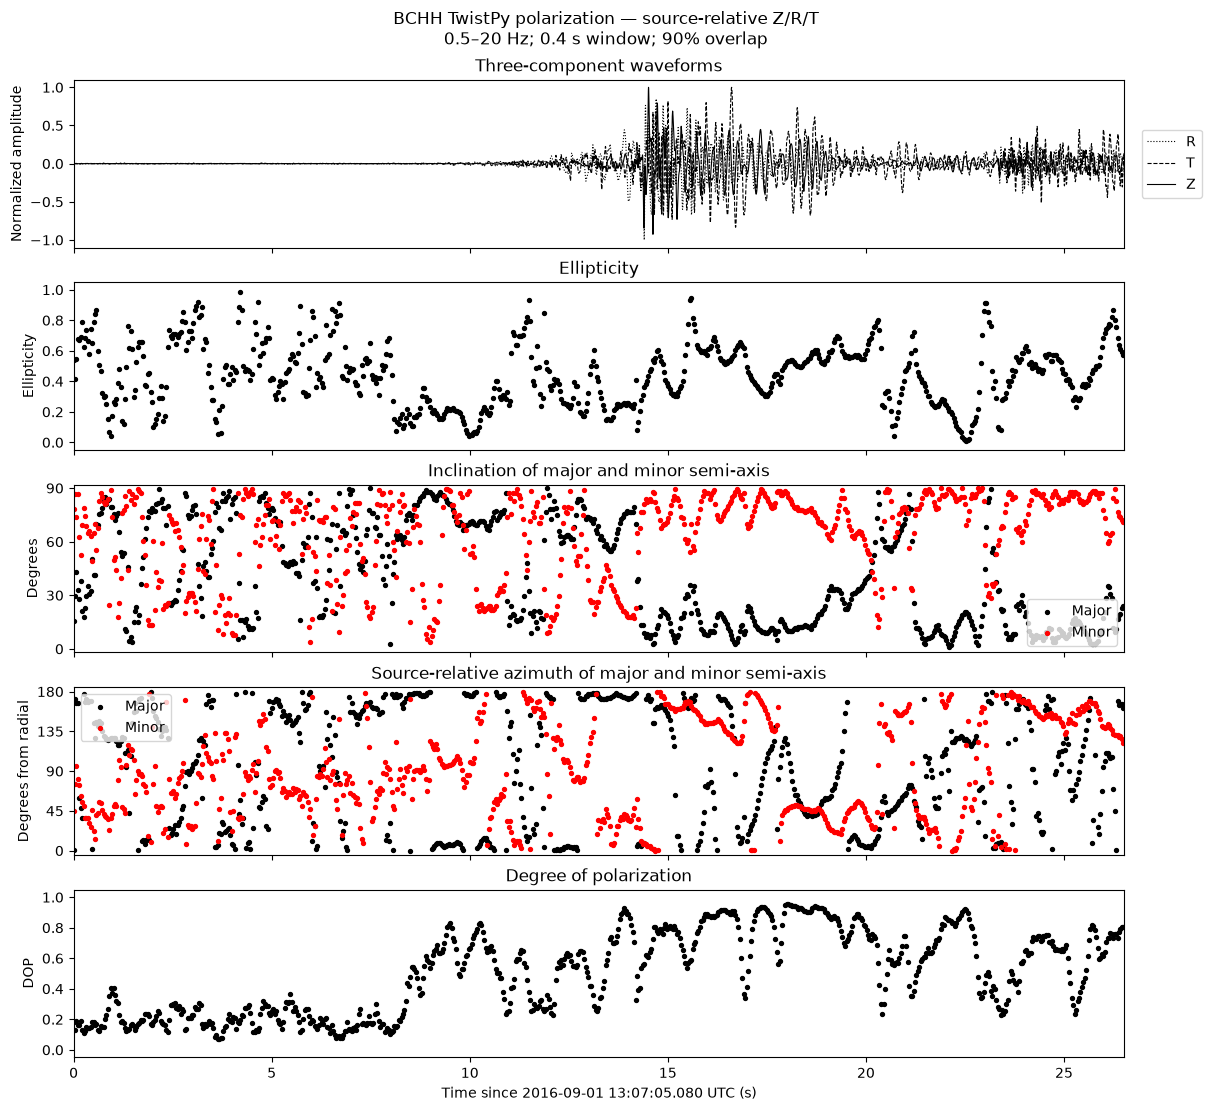

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_style_zrt.png


In [25]:
# Broad-context TwistPy-style figures.
plot_twistpy_style(
    st_analysis_zne,
    components=("N", "E", "Z"),
    labels=("N", "E", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="geographic",
    output_path=TWISTPY_ZNE_FIGURE,
    title="BCHH TwistPy polarization — geographic Z/N/E",
)

plot_twistpy_style(
    st_analysis_zrt,
    components=("R", "T", "Z"),
    labels=("R", "T", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="source_relative",
    output_path=TWISTPY_ZRT_FIGURE,
    title="BCHH TwistPy polarization — source-relative Z/R/T",
)


In [26]:
def robust_symmetric_ylim(
    values: np.ndarray,
    percentile: float = 99.5,
    padding: float = 1.08,
) -> tuple[float, float]:
    """Return robust symmetric limits from the samples currently displayed."""
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return -1.0, 1.0

    amplitude = np.nanpercentile(np.abs(finite), percentile)
    if not np.isfinite(amplitude) or amplitude <= 0.0:
        amplitude = np.nanmax(np.abs(finite))
    if not np.isfinite(amplitude) or amplitude <= 0.0:
        amplitude = 1.0
    amplitude *= padding
    return -amplitude, amplitude


def make_zrt_polarization_zoom(
    *,
    reference_time: UTCDateTime,
    event_label: str,
    zoom_start_s: float,
    zoom_end_s: float,
    output_path: Path,
    common_waveform_scale: bool,
    candidate_pick_s: float | None = None,
    candidate_pick_uncertainty_s: float | None = None,
    predicted_airwave_delay_s: float | None = ACOUSTIC_TRAVEL_TIME_S,
) -> None:
    """Plot event-relative Z/R/T waveforms and polarization attributes."""
    reference_time = UTCDateTime(reference_time)
    plot_start = reference_time + float(zoom_start_s)
    plot_end = reference_time + float(zoom_end_s)
    if plot_end <= plot_start:
        raise ValueError(f"Invalid plot interval: {plot_start} to {plot_end}")

    plot_stream = st_analysis_zrt.copy().trim(plot_start, plot_end, pad=False)
    plot_pol = subset_polarization(plot_start, plot_end)
    plot_pol["event_relative_time_s"] = (
        plot_pol["time_epoch_s"] - utc_epoch_seconds(reference_time)
    )

    waveform_data = {}
    for component in ("Z", "R", "T"):
        trace = unique_component(plot_stream, component)
        waveform_data[component] = {
            "time_s": trace.times(reftime=reference_time),
            "data": np.asarray(trace.data, dtype=float),
        }

    common_ylim = None
    if common_waveform_scale:
        common_ylim = robust_symmetric_ylim(
            np.concatenate([
                waveform_data[component]["data"]
                for component in ("Z", "R", "T")
            ])
        )

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 11), sharex=True, constrained_layout=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 0.95, 0.95]},
    )

    for ax, component in zip(axes[:3], ("Z", "R", "T")):
        time_s = waveform_data[component]["time_s"]
        data = waveform_data[component]["data"]
        ax.plot(time_s, data, color="black", lw=0.8)
        ax.set_ylabel(f"{component}\n(m s$^{{-1}}$)")
        ax.set_ylim(*(common_ylim or robust_symmetric_ylim(data)))
        ax.grid(True, axis="x", alpha=0.20)

    relative_time_s = plot_pol["event_relative_time_s"]
    axes[3].plot(relative_time_s, plot_pol["linearity"], label="Linearity", lw=1.0)
    axes[3].plot(relative_time_s, plot_pol["rectilinearity"], label="Rectilinearity", lw=1.0)
    axes[3].plot(relative_time_s, plot_pol["planarity"], label="Planarity", lw=1.0)
    axes[3].set_ylim(-0.05, 1.05)
    axes[3].set_ylabel("Covariance\nattributes")
    axes[3].legend(loc="upper right", ncol=3)
    axes[3].grid(True, alpha=0.20)

    axes[4].plot(relative_time_s, plot_pol["ellipticity"], label="Ellipticity", lw=1.0)
    axes[4].plot(
        relative_time_s,
        plot_pol["degree_of_polarization"],
        label="TwistPy DOP",
        lw=1.0,
    )
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("TwistPy\nattributes")
    axes[4].set_xlabel(f"Time relative to adopted {event_label} time (s)")
    axes[4].legend(loc="upper right", ncol=2)
    axes[4].grid(True, alpha=0.20)

    for panel_index, ax in enumerate(axes):
        ax.axvline(
            0.0,
            color="tab:red",
            lw=0.9,
            ls="--",
            label=f"{event_label} source time" if panel_index == 0 else None,
        )
        if predicted_airwave_delay_s is not None:
            ax.axvline(
                predicted_airwave_delay_s,
                color="tab:blue",
                lw=0.9,
                ls="--",
                label="Predicted acoustic arrival" if panel_index == 0 else None,
            )
        if candidate_pick_s is not None:
            uncertainty = float(candidate_pick_uncertainty_s or 0.0)
            if uncertainty > 0.0:
                ax.axvspan(
                    candidate_pick_s - uncertainty,
                    candidate_pick_s + uncertainty,
                    color="tab:green",
                    alpha=0.12,
                    lw=0,
                )
            ax.axvline(
                candidate_pick_s,
                color="tab:green",
                lw=1.0,
                ls=":",
                label="Candidate P arrival" if panel_index == 0 else None,
            )

    axes[0].legend(loc="upper left")
    axes[-1].set_xlim(float(zoom_start_s), float(zoom_end_s))

    scale_description = (
        "common Z/R/T scale" if common_waveform_scale
        else "independent component scales"
    )
    fig.suptitle(
        f"BCHH Z/R/T polarization overview — {event_label}\n"
        f"{FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
        f"{WINDOW_LENGTH_S:g} s window; "
        f"zoom={zoom_start_s:g} to {zoom_end_s:g} s; "
        f"{scale_description}"
    )
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


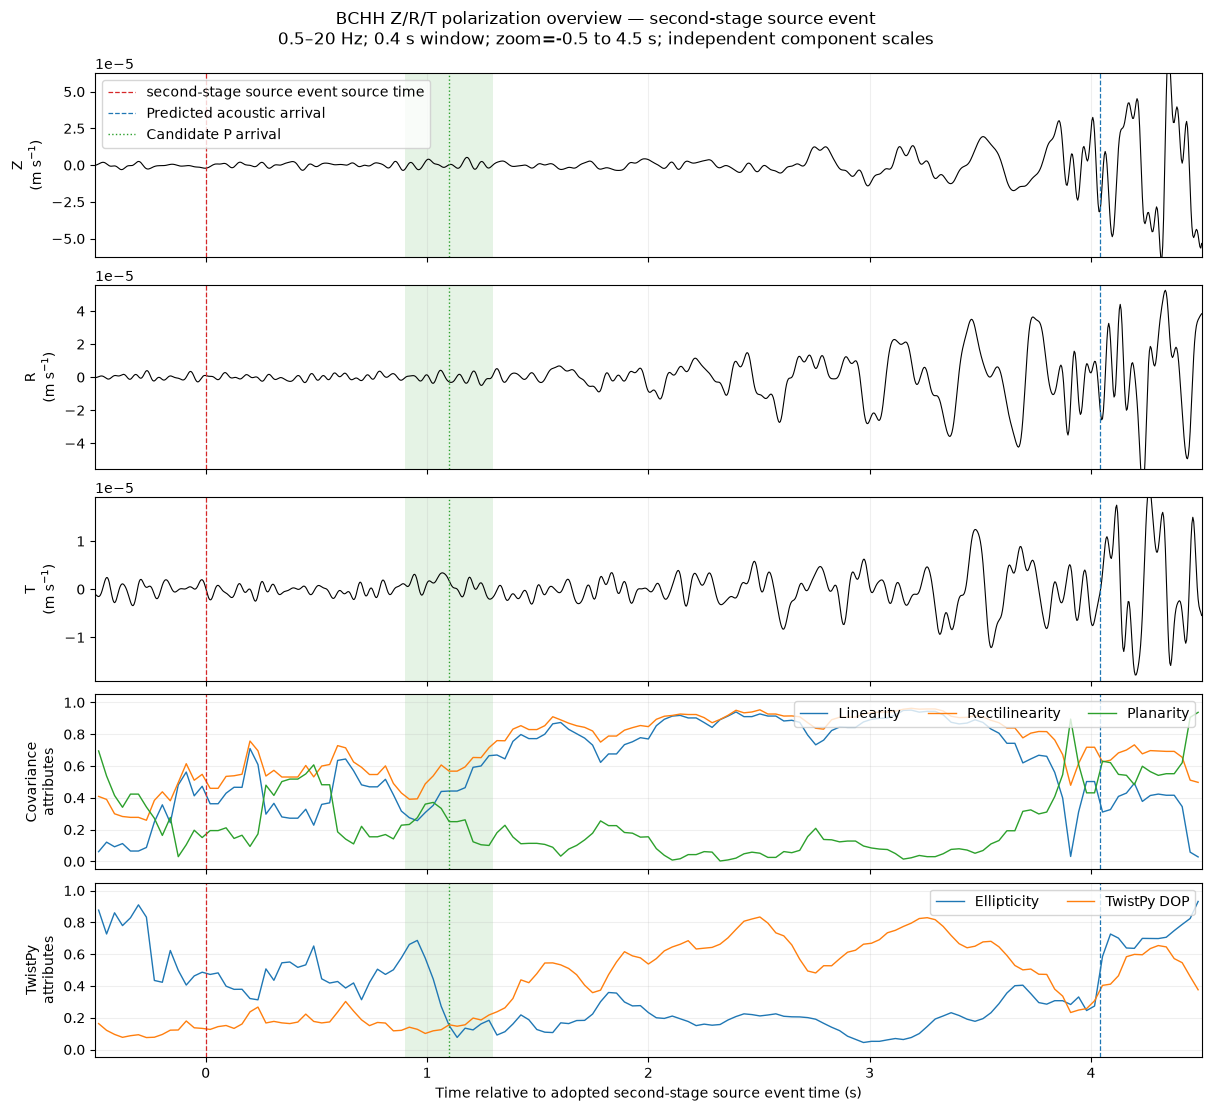

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_second_stage_zoom_independent_scale.png


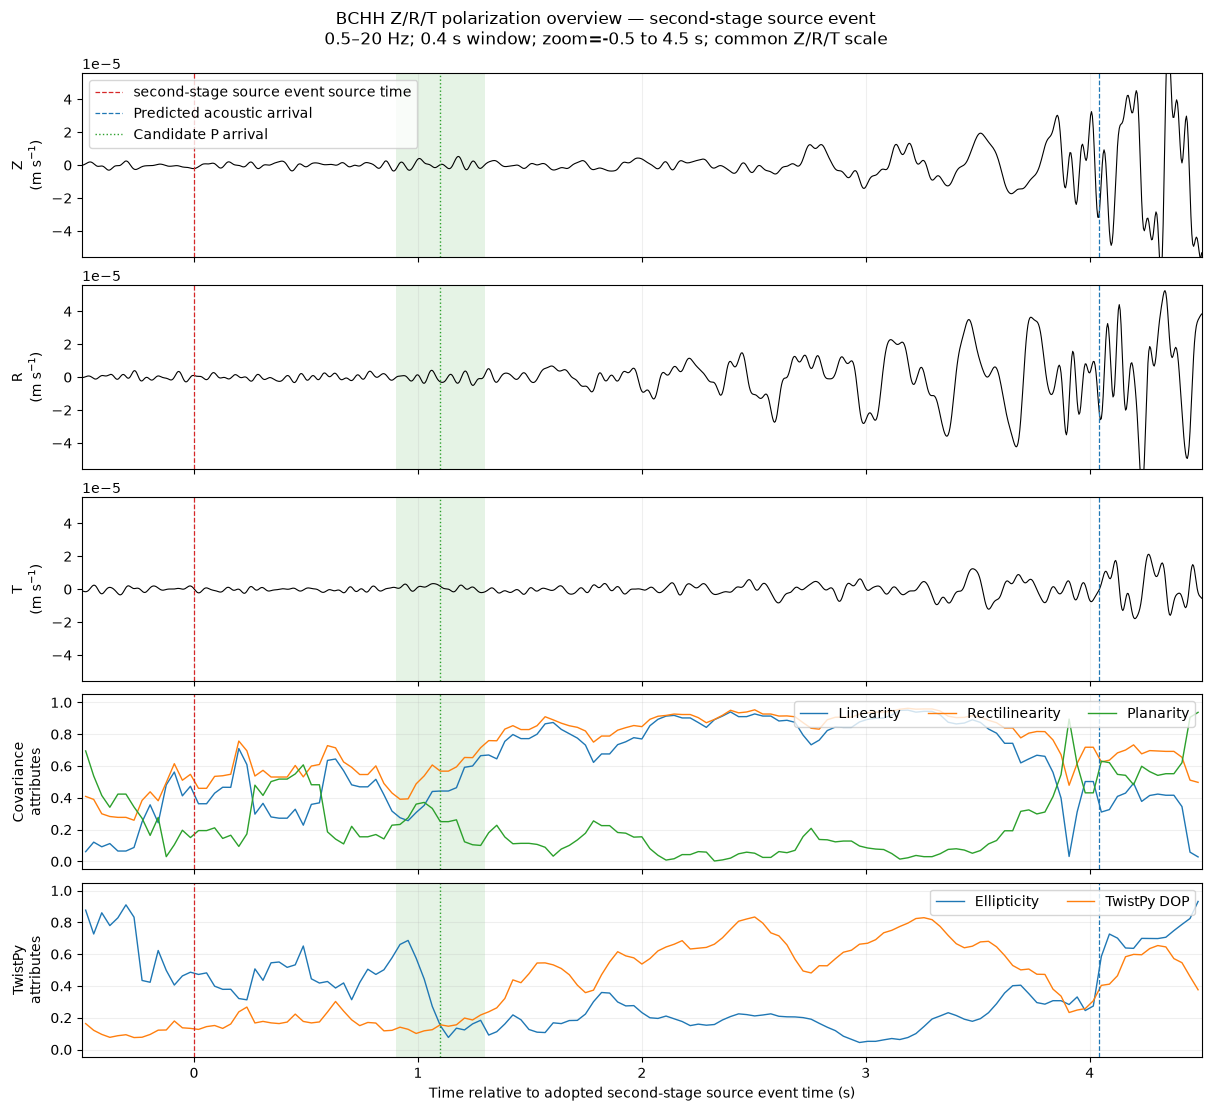

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_second_stage_zoom_common_scale.png


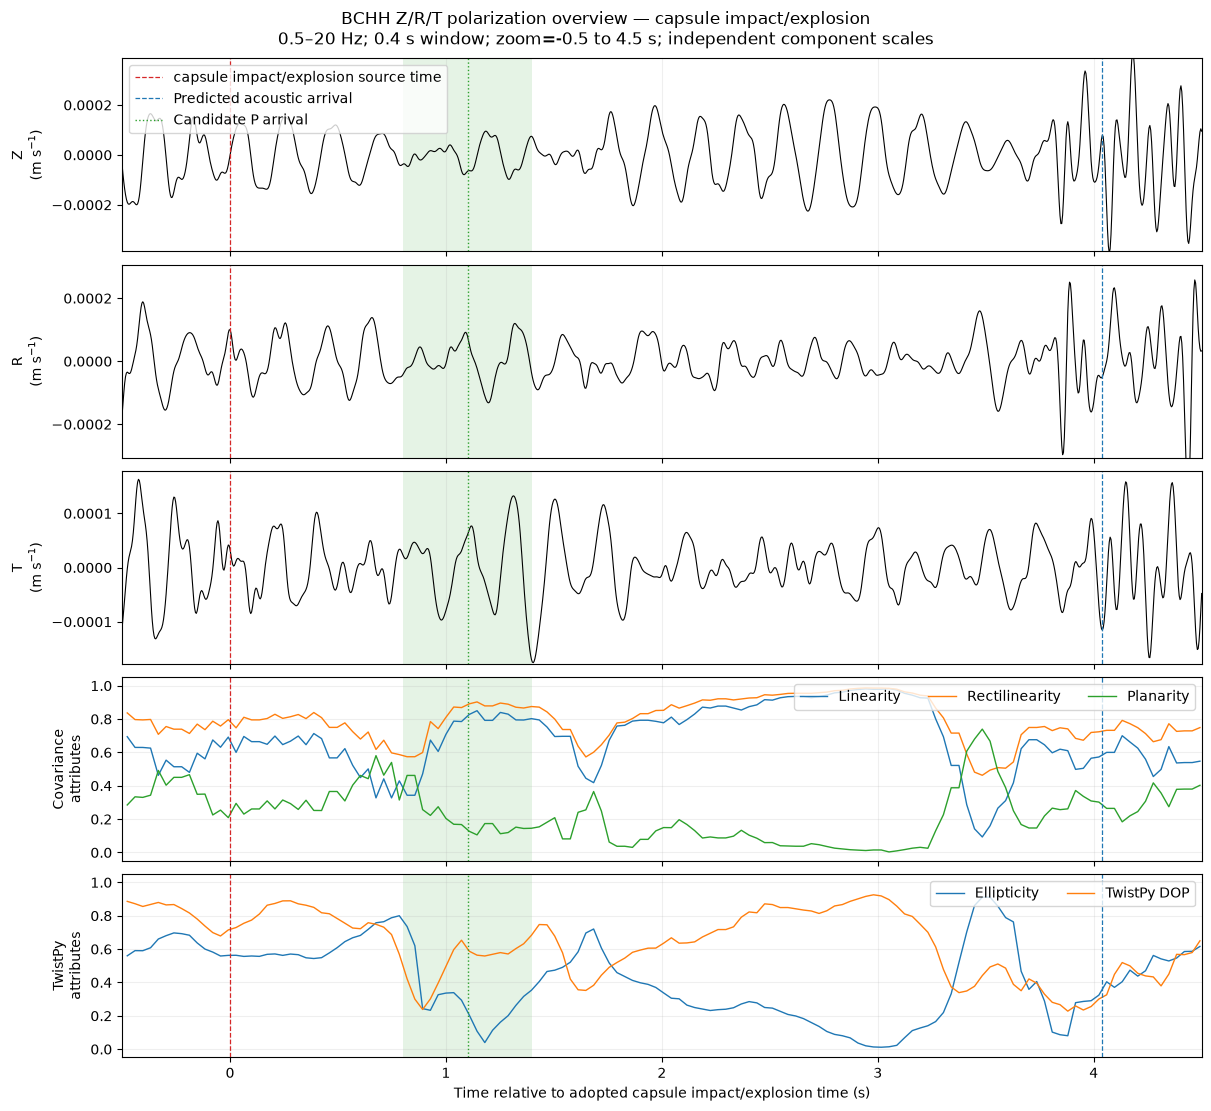

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_capsule_zoom_independent_scale.png


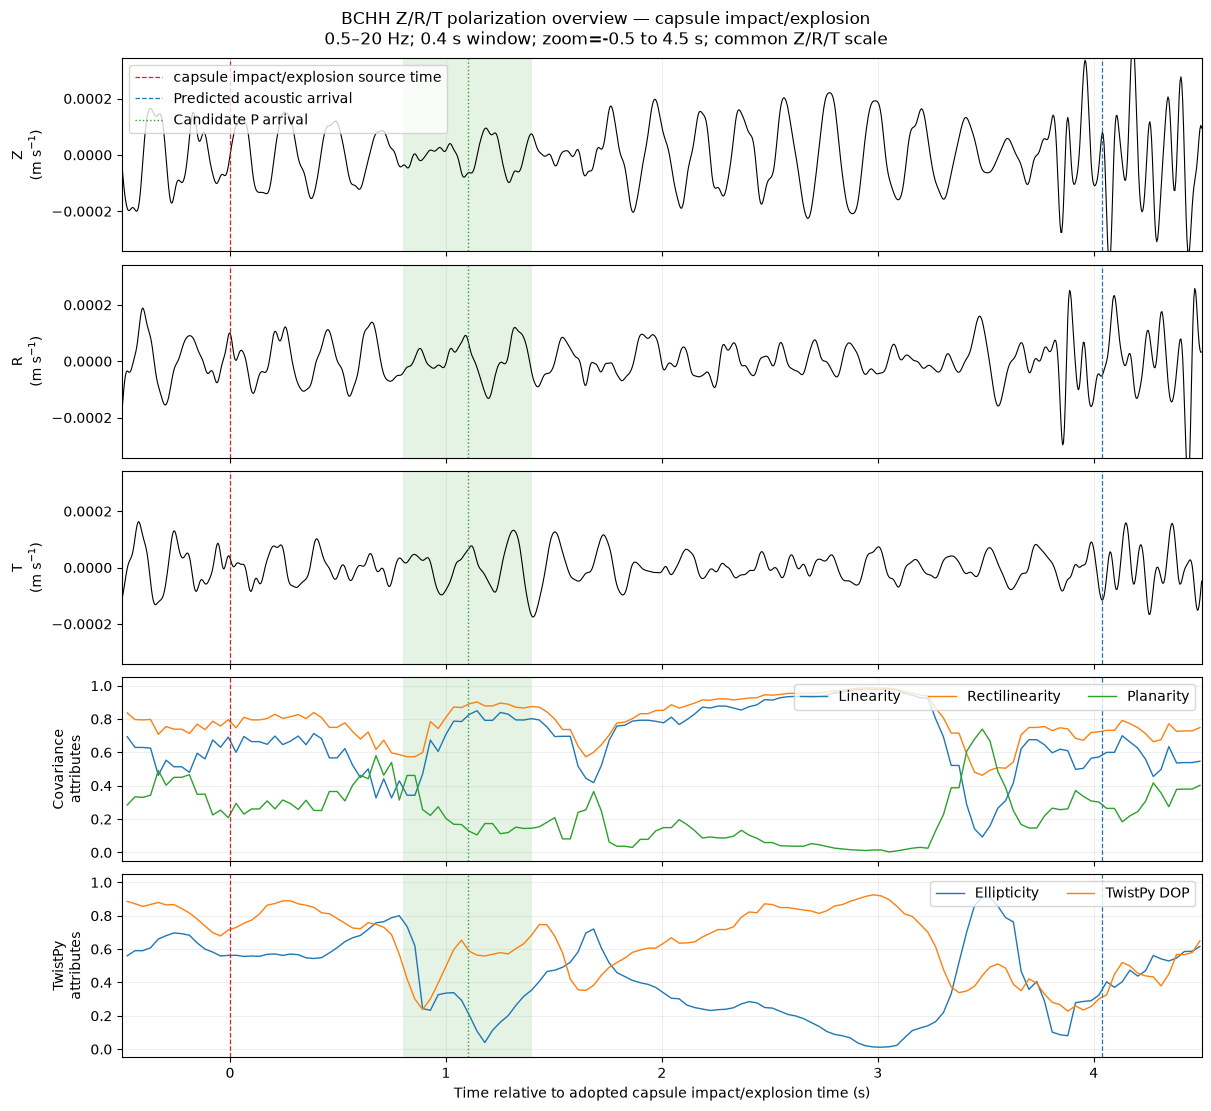

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_capsule_zoom_common_scale.png


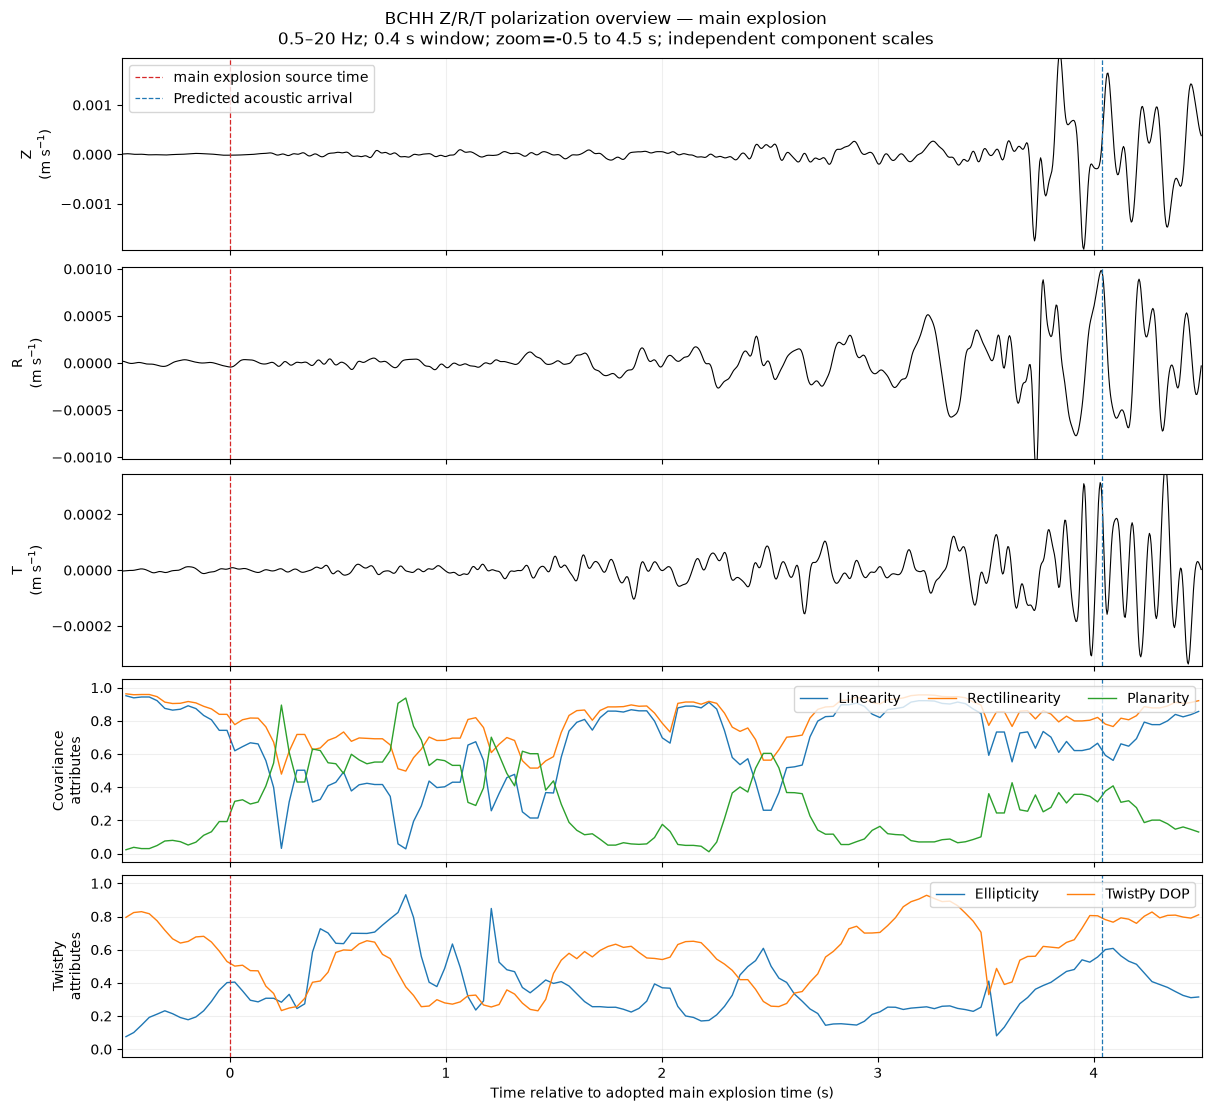

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_main_explosion_zoom_independent_scale.png


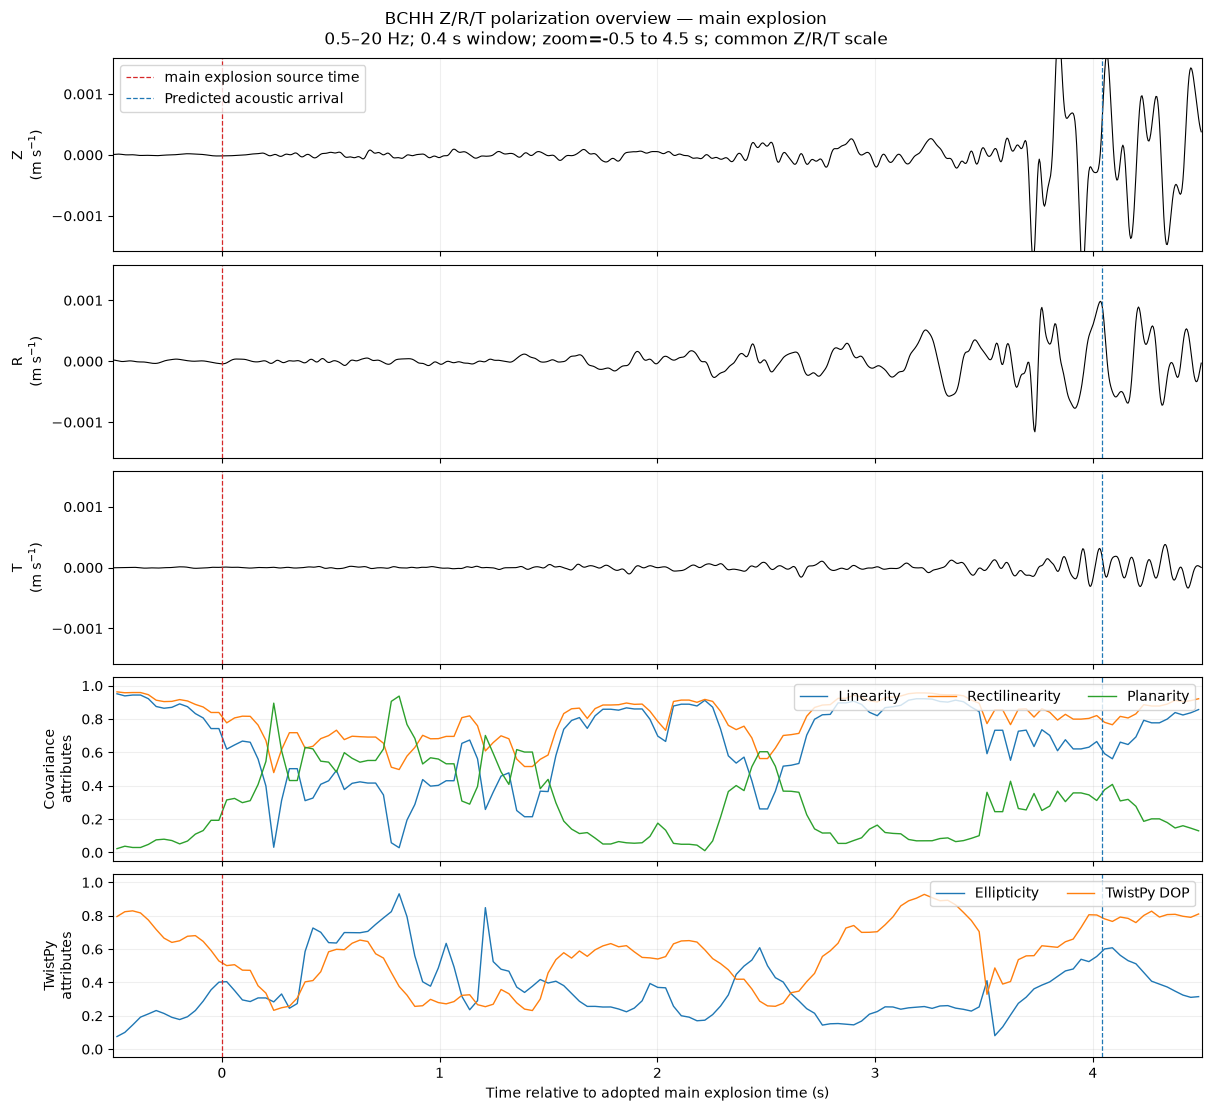

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_main_explosion_zoom_common_scale.png


,event,event_label,source_time_utc,candidate_p_travel_time_s,uncertainty_s
0,second_stage,second-stage source event,2016-09-01T13:07:12.080000Z,1.1,0.2
1,capsule,capsule impact/explosion,2016-09-01T13:07:24.600000Z,1.1,0.3


Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_provisional_p_wave_picks.csv


In [27]:
EVENT_FIGURES = {}
pick_rows = []

for event_key, event_cfg in EVENT_ZOOMS.items():
    pick_cfg = PROVISIONAL_P_PICKS.get(event_key)
    independent_path = (
        config.FIGURE_DIR / f"12_zrt_{event_key}_zoom_independent_scale.png"
    )
    common_path = (
        config.FIGURE_DIR / f"12_zrt_{event_key}_zoom_common_scale.png"
    )

    common_kwargs = {
        "reference_time": event_cfg["time"],
        "event_label": event_cfg["label"],
        "zoom_start_s": event_cfg["zoom"][0],
        "zoom_end_s": event_cfg["zoom"][1],
        "candidate_pick_s": None if pick_cfg is None else pick_cfg["travel_time_s"],
        "candidate_pick_uncertainty_s": (
            None if pick_cfg is None else pick_cfg["uncertainty_s"]
        ),
    }

    make_zrt_polarization_zoom(
        **common_kwargs,
        output_path=independent_path,
        common_waveform_scale=False,
    )
    make_zrt_polarization_zoom(
        **common_kwargs,
        output_path=common_path,
        common_waveform_scale=True,
    )

    EVENT_FIGURES[f"{event_key}_independent"] = independent_path
    EVENT_FIGURES[f"{event_key}_common"] = common_path

    if pick_cfg is not None:
        pick_rows.append({
            "event": event_key,
            "event_label": event_cfg["label"],
            "source_time_utc": str(event_cfg["time"]),
            "candidate_p_travel_time_s": pick_cfg["travel_time_s"],
            "uncertainty_s": pick_cfg["uncertainty_s"],
        })

PROVISIONAL_P_PICK_TABLE = OUTPUT_ROOT / "12_provisional_p_wave_picks.csv"
provisional_p_picks = pd.DataFrame(pick_rows)
provisional_p_picks.to_csv(PROVISIONAL_P_PICK_TABLE, index=False)
display(provisional_p_picks)
print("Saved:", PROVISIONAL_P_PICK_TABLE)


## 9. Focused multiband search for direct seismic arrivals

The following analysis uses one common time window spanning pre-event noise, the second-stage onset, the principal sequence, and the capsule event. It repeats the TwistPy calculation independently in several bands.

Interpretation guide:

- A candidate **direct P arrival** should precede the predicted acoustic arrival, have elevated DOP, and usually show a steep major-axis inclination with predominantly vertical/radial motion.
- A candidate **direct S arrival** may be more horizontal and could have stronger transverse motion, but its timing must still precede the acoustic arrival expected from the same source event.
- The **ground-coupled airwave/Rayleigh wave** should occur near the predicted acoustic arrival, be strong in the 3–10 Hz band, and may show Z/R elliptical motion and high DOP.
- Event markers are source times. Dashed markers are predicted acoustic arrivals. Shaded intervals are only direct-seismic search windows.


Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


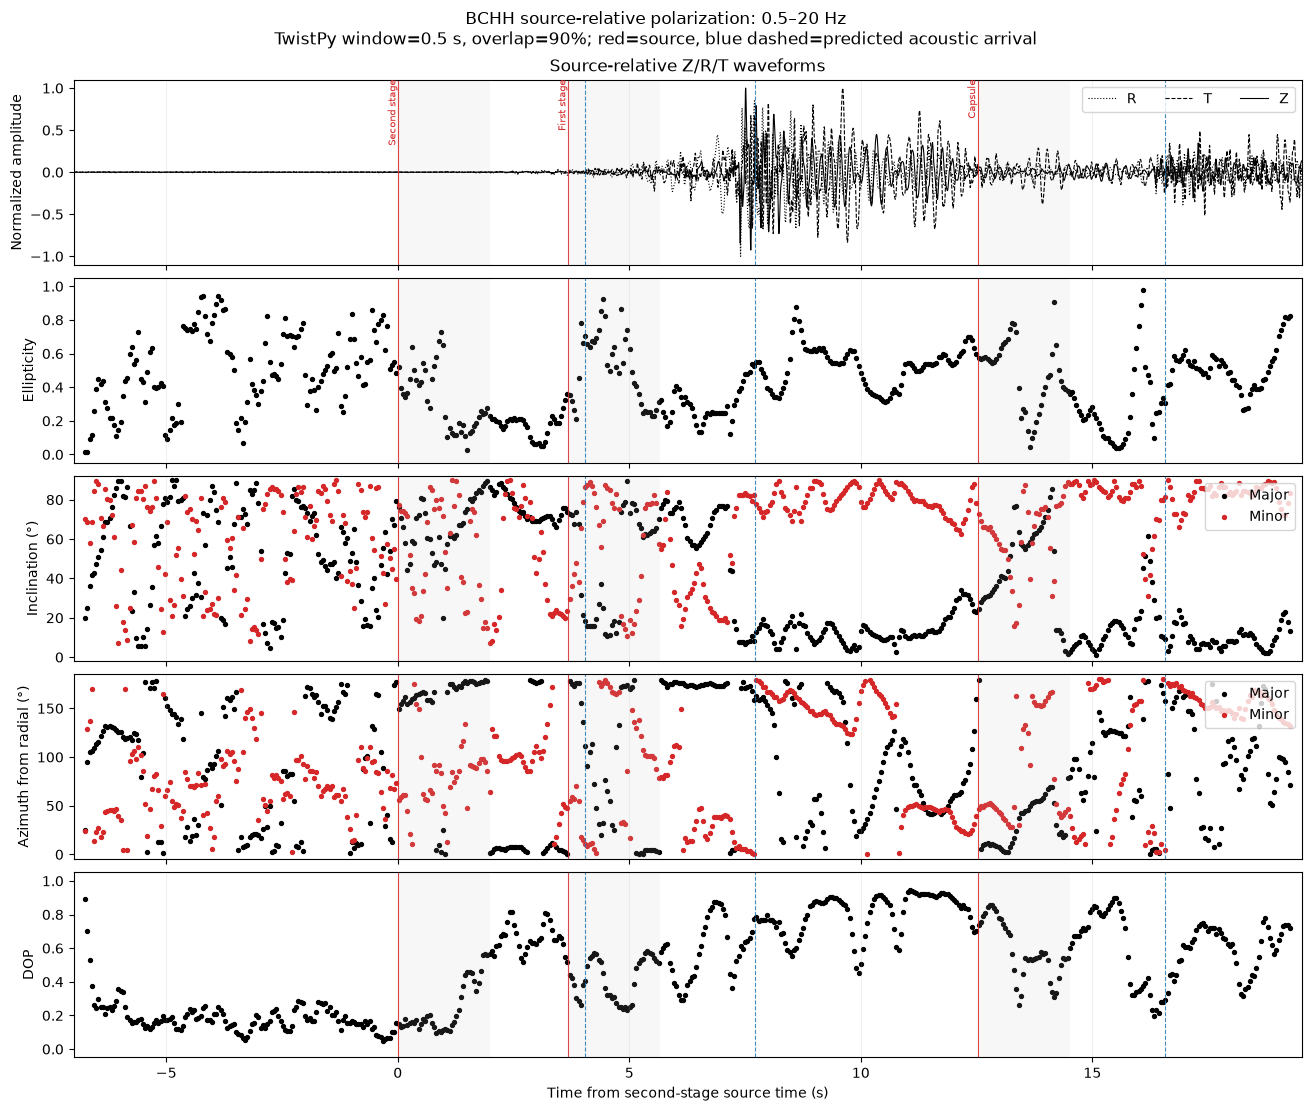

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_source_relative_broad_0p5_20.png
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


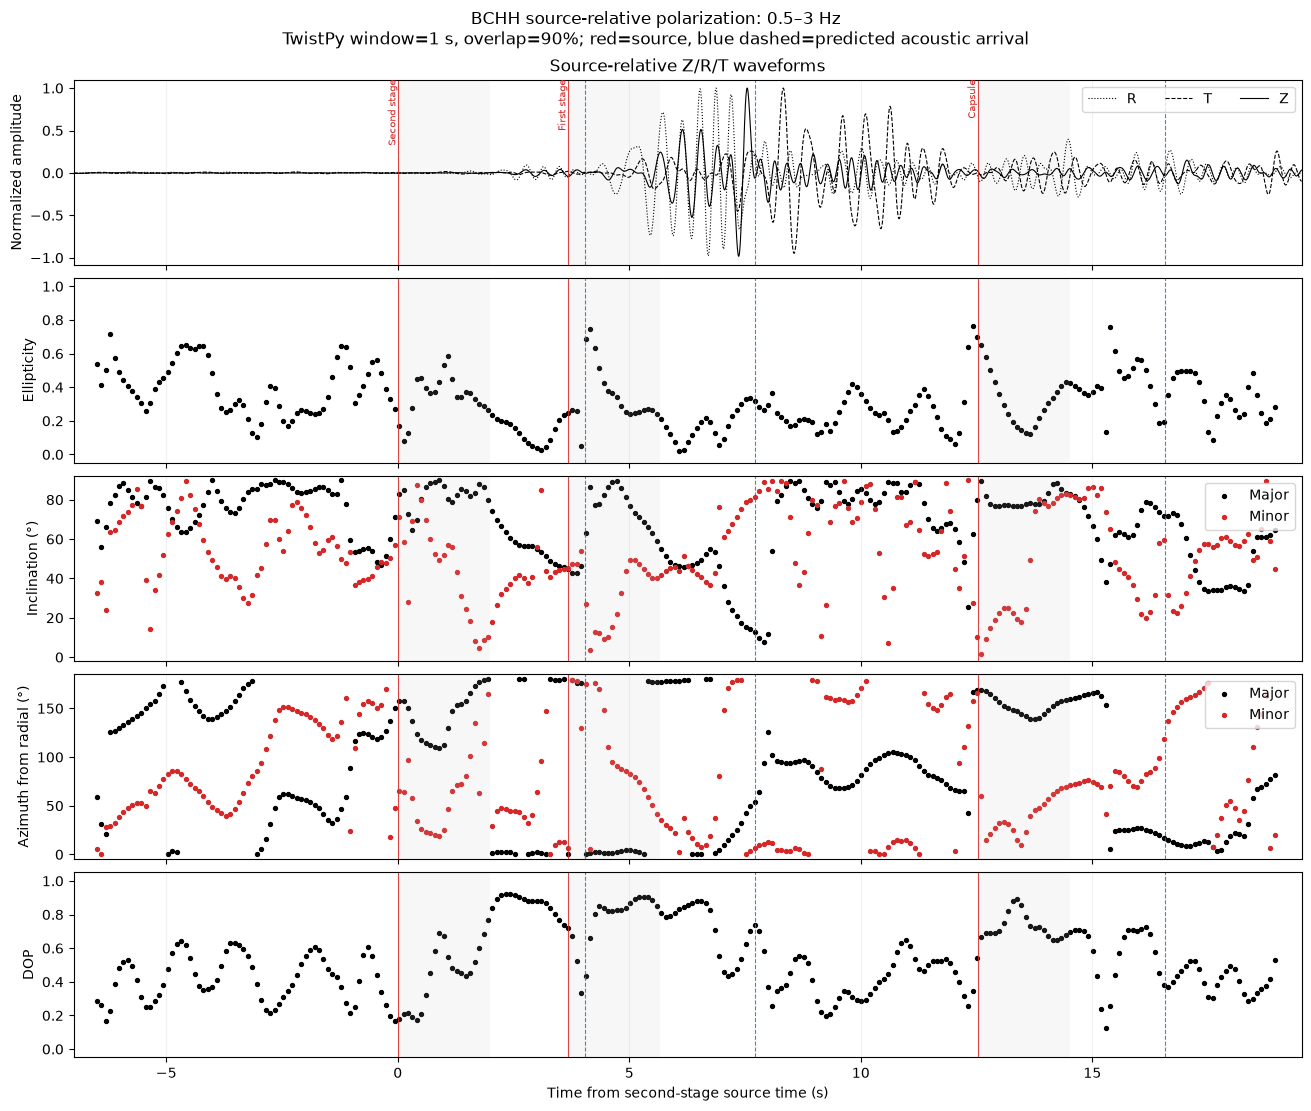

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_source_relative_low_0p5_3.png
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


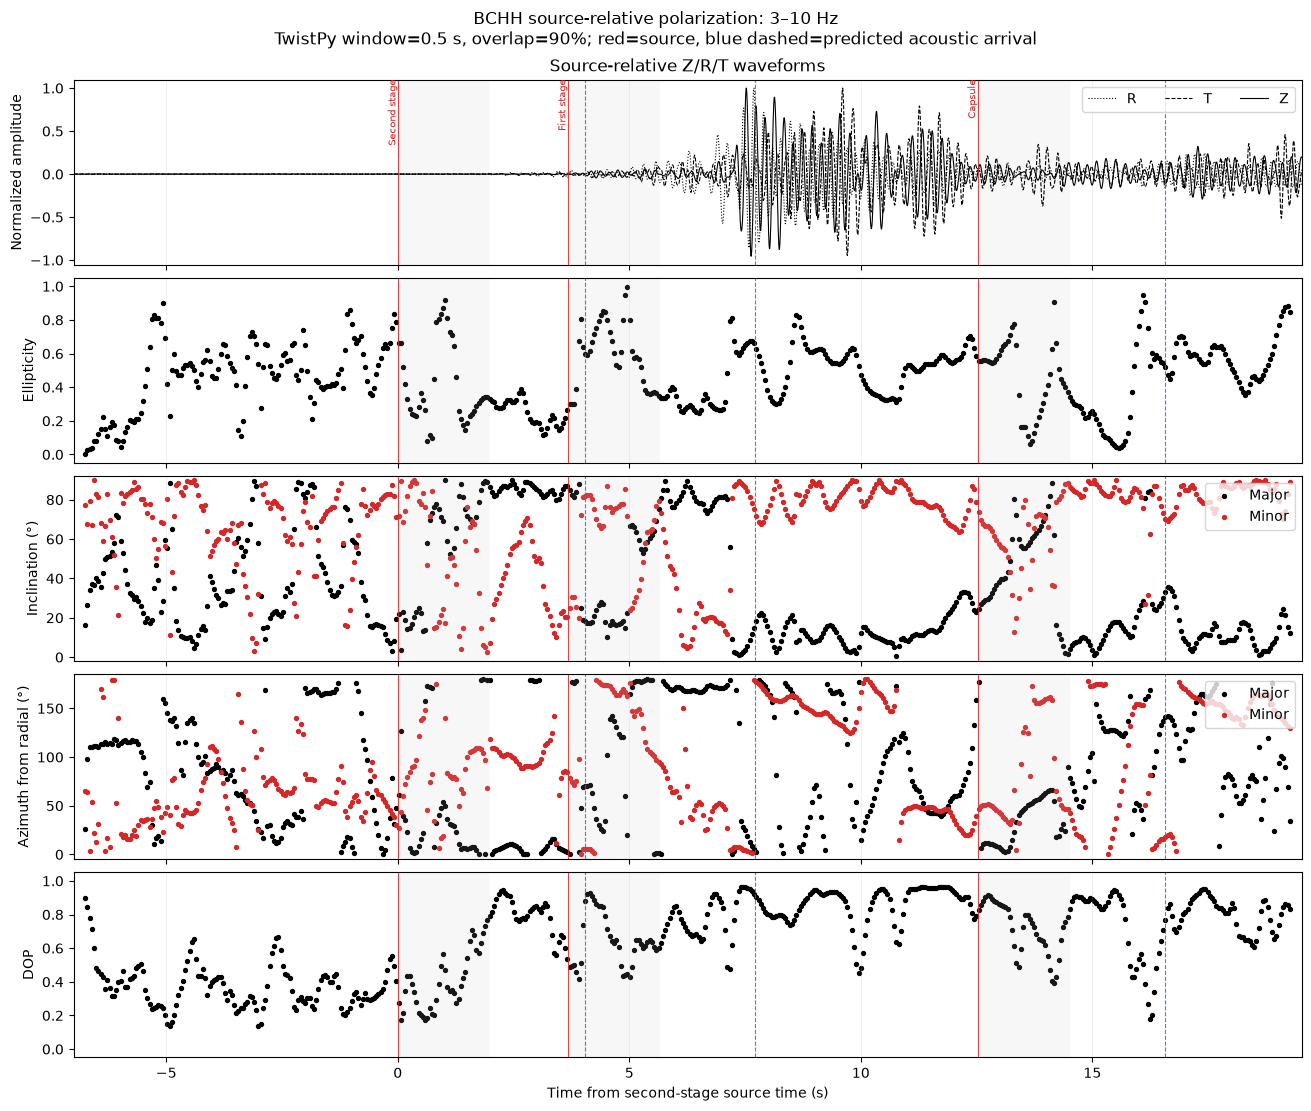

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_source_relative_airwave_3_10.png
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


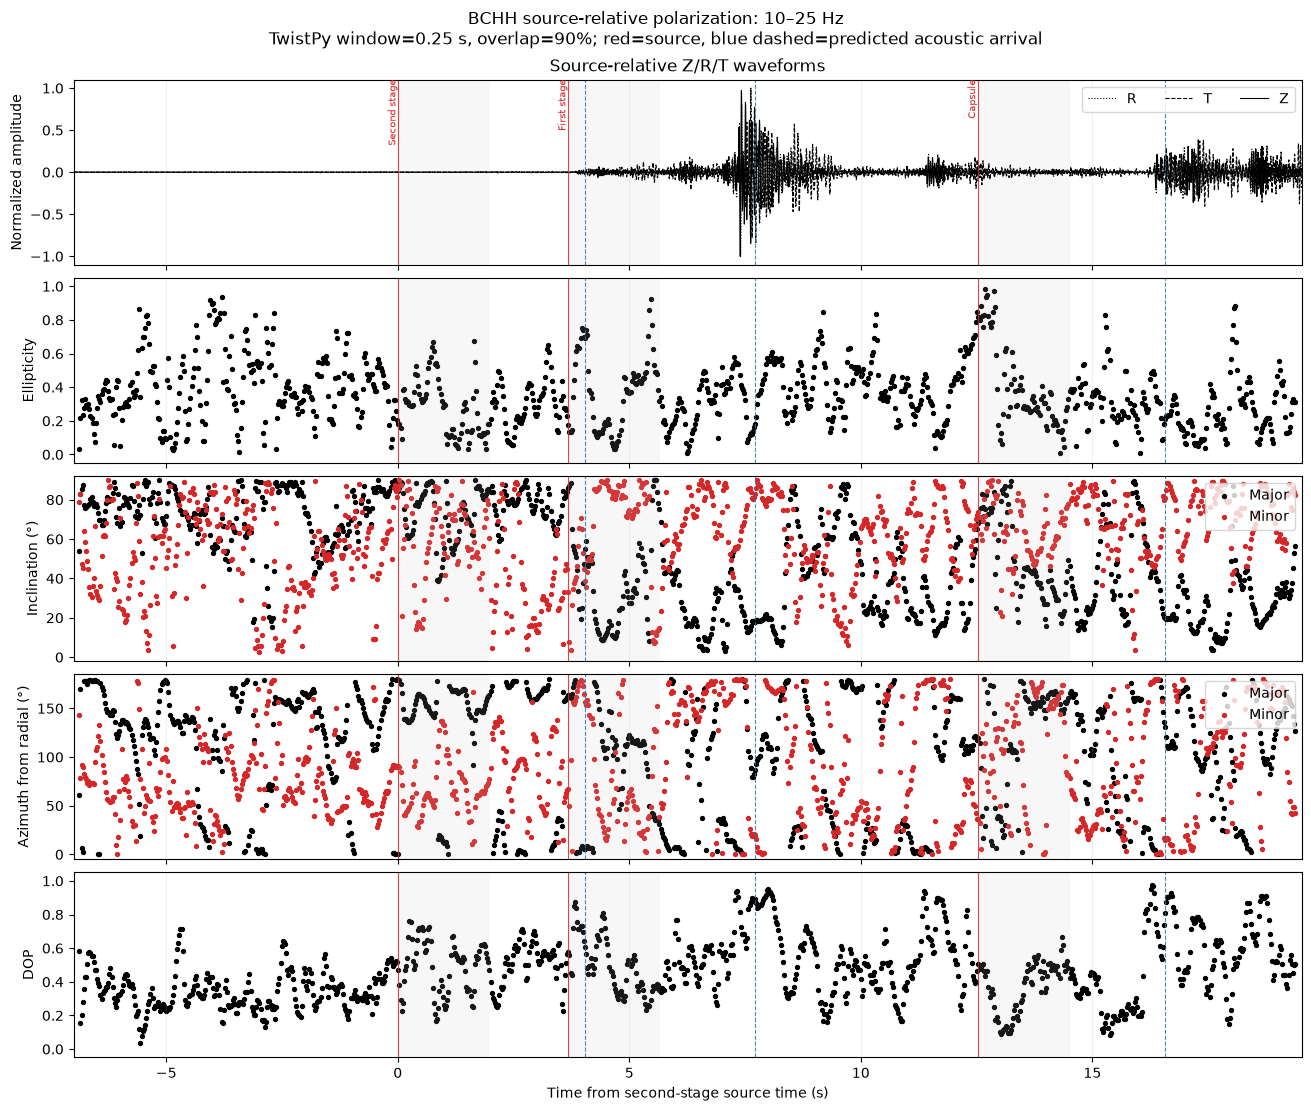

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_source_relative_high_10_25.png
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


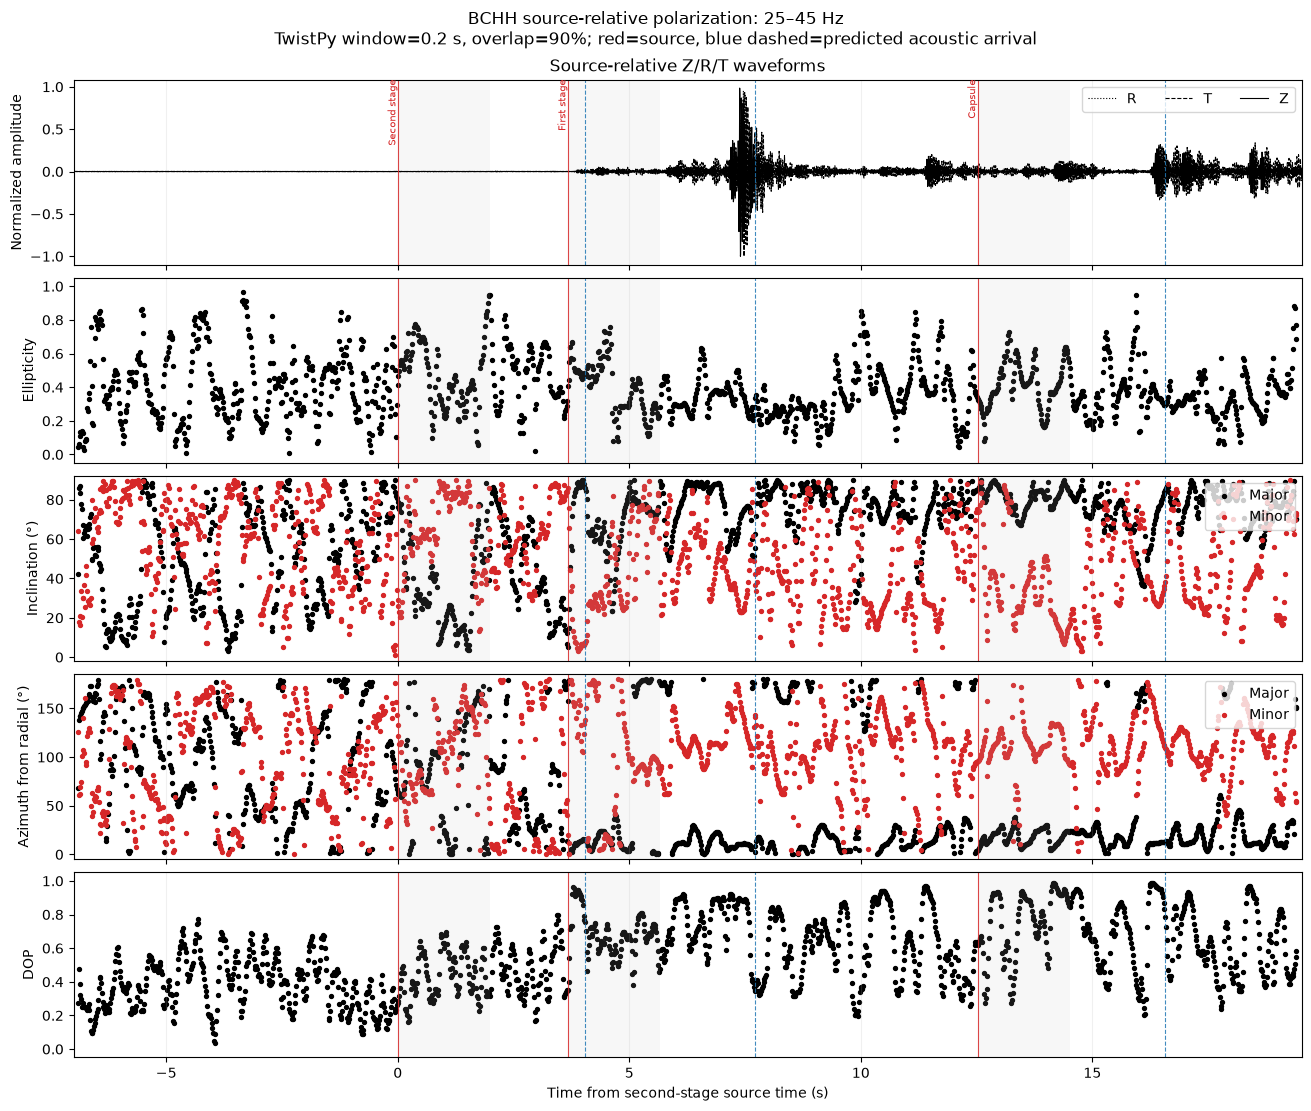

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_source_relative_very_high_25_45.png
Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/multiband/12_multiband_polarization_timeseries.csv


,windows,median_dop,median_ellipticity
band,,,
airwave_3_10,543,0.683149,0.482984
broad_0p5_20,543,0.527030,0.444635
high_10_25,1095,0.446688,0.336709
low_0p5_3,266,0.522705,0.295863
very_high_25_45,1645,0.557931,0.366753


In [28]:
def valid_band_for_stream(
    stream: Stream,
    freqmin_hz: float,
    freqmax_hz: float,
) -> tuple[float, float]:
    """Clip an exploratory band to a safe fraction of the stream Nyquist."""
    sampling_rate = min(float(tr.stats.sampling_rate) for tr in stream)
    nyquist = 0.5 * sampling_rate
    safe_max = 0.95 * nyquist
    fmin = float(freqmin_hz)
    fmax = min(float(freqmax_hz), safe_max)
    if fmin >= fmax:
        raise ValueError(
            f"Band {freqmin_hz}-{freqmax_hz} Hz is invalid for "
            f"sampling rate {sampling_rate:g} Hz (Nyquist={nyquist:g} Hz)."
        )
    return fmin, fmax


def prepare_band_stream(
    stream: Stream,
    freqmin_hz: float,
    freqmax_hz: float,
) -> Stream:
    """Trim with padding, preprocess, bandpass, then trim to the focus window."""
    fmin, fmax = valid_band_for_stream(stream, freqmin_hz, freqmax_hz)
    padding_s = max(5.0, 3.0 / fmin)
    out = stream.copy().trim(PLOT_START - padding_s, PLOT_END + padding_s, pad=False)
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.05, type="cosine")
    out.filter(
        "bandpass",
        freqmin=fmin,
        freqmax=fmax,
        corners=FILTER_CORNERS,
        zerophase=FILTER_ZEROPHASE,
    )
    out.trim(PLOT_START, PLOT_END, pad=False)
    return out


def twistpy_dataframe_for_band(
    st_zne_band: Stream,
    *,
    band_name: str,
    freqmin_hz: float,
    freqmax_hz: float,
    window_length_s: float,
) -> pd.DataFrame:
    """Run TwistPy on one Z/N/E band and return an absolute-time table."""
    z_band = unique_component(st_zne_band, "Z")
    n_band = unique_component(st_zne_band, "N")
    e_band = unique_component(st_zne_band, "E")
    assert_sample_aligned((z_band, n_band, e_band))

    analysis_band = TimeDomainAnalysis3C(
        N=n_band,
        E=e_band,
        Z=z_band,
        window={
            "window_length_seconds": float(window_length_s),
            "overlap": float(WINDOW_OVERLAP),
        },
        timeaxis="rel",
    )
    analysis_band.polarization_analysis()

    relative_s = np.asarray(analysis_band.t_windows, dtype=float)
    start_epoch = utc_epoch_seconds(z_band.stats.starttime)
    time_epoch_s = start_epoch + relative_s

    result = pd.DataFrame({
        "band": band_name,
        "freqmin_hz": freqmin_hz,
        "freqmax_hz": freqmax_hz,
        "window_length_s": window_length_s,
        "time_epoch_s": time_epoch_s,
        "time_from_second_stage_s": time_epoch_s - utc_epoch_seconds(SECOND_STAGE_SOURCE_TIME),
        "ellipticity": np.asarray(analysis_band.elli, dtype=float),
        "degree_of_polarization": np.asarray(analysis_band.dop, dtype=float),
        "major_azimuth_deg": np.asarray(analysis_band.azi1, dtype=float) % 180.0,
        "minor_azimuth_deg": np.asarray(analysis_band.azi2, dtype=float) % 180.0,
        "major_inclination_deg": np.asarray(analysis_band.inc1, dtype=float),
        "minor_inclination_deg": np.asarray(analysis_band.inc2, dtype=float),
    })
    result["major_source_relative_azimuth_deg"] = (
        result["major_azimuth_deg"] - back_azimuth_deg
    ) % 180.0
    result["minor_source_relative_azimuth_deg"] = (
        result["minor_azimuth_deg"] - back_azimuth_deg
    ) % 180.0
    result["time_utc"] = [str(UTCDateTime(v)) for v in result["time_epoch_s"]]
    return result


def add_event_timing_annotations(ax, *, include_labels: bool = False) -> None:
    """Add source times, direct-wave search windows, and acoustic arrivals."""
    ymin, ymax = ax.get_ylim()
    for index, (label, source_time) in enumerate(SOURCE_EVENTS.items()):
        source_x = float(source_time - SECOND_STAGE_SOURCE_TIME)
        acoustic_x = source_x + ACOUSTIC_TRAVEL_TIME_S
        ax.axvspan(
            source_x + DIRECT_SEISMIC_SEARCH_MIN_S,
            source_x + DIRECT_SEISMIC_SEARCH_MAX_S,
            color="0.75",
            alpha=0.12,
            lw=0,
        )
        ax.axvline(source_x, color="tab:red", lw=0.8, alpha=EVENT_MARKER_ALPHA)
        ax.axvline(acoustic_x, color="tab:blue", lw=0.8, ls="--", alpha=EVENT_MARKER_ALPHA)
        if include_labels:
            ax.text(
                source_x,
                ymax,
                label,
                rotation=90,
                ha="right",
                va="top",
                fontsize=7,
                color="tab:red",
            )


multiband_frames = []
multiband_streams_zrt = {}

for band_name, (requested_fmin, requested_fmax) in POLARIZATION_BANDS_HZ.items():
    fmin, fmax = valid_band_for_stream(st_zne, requested_fmin, requested_fmax)
    st_band_zne = prepare_band_stream(st_zne, fmin, fmax)
    st_band_zrt = prepare_band_stream(st_zrt, fmin, fmax)
    multiband_streams_zrt[band_name] = st_band_zrt

    window_length_s = BAND_WINDOW_LENGTH_S[band_name]
    band_df = twistpy_dataframe_for_band(
        st_band_zne,
        band_name=band_name,
        freqmin_hz=fmin,
        freqmax_hz=fmax,
        window_length_s=window_length_s,
    )
    multiband_frames.append(band_df)

    output_path = config.FIGURE_DIR / f"12_twistpy_source_relative_{band_name}.png"
    fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True, constrained_layout=True)

    for component, linestyle in zip(("R", "T", "Z"), (":", "--", "-")):
        tr = unique_component(st_band_zrt, component)
        axes[0].plot(
            tr.times(reftime=SECOND_STAGE_SOURCE_TIME),
            normalized_data(tr),
            color="black",
            ls=linestyle,
            lw=0.8,
            label=component,
        )
    axes[0].set_ylabel("Normalized amplitude")
    axes[0].set_title("Source-relative Z/R/T waveforms")
    axes[0].legend(loc="upper right", ncol=3)

    x = band_df["time_from_second_stage_s"]
    axes[1].scatter(x, band_df["ellipticity"], s=8, c="black")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Ellipticity")

    axes[2].scatter(x, band_df["major_inclination_deg"], s=8, c="black", label="Major")
    axes[2].scatter(x, band_df["minor_inclination_deg"], s=8, c="tab:red", label="Minor")
    axes[2].set_ylim(-2, 92)
    axes[2].set_ylabel("Inclination (°)")
    axes[2].legend(loc="upper right")

    axes[3].scatter(x, band_df["major_source_relative_azimuth_deg"], s=8, c="black", label="Major")
    axes[3].scatter(x, band_df["minor_source_relative_azimuth_deg"], s=8, c="tab:red", label="Minor")
    axes[3].set_ylim(-5, 185)
    axes[3].set_ylabel("Azimuth from radial (°)")
    axes[3].legend(loc="upper right")

    axes[4].scatter(x, band_df["degree_of_polarization"], s=8, c="black")
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("DOP")
    axes[4].set_xlabel("Time from second-stage source time (s)")

    for panel_index, ax in enumerate(axes):
        add_event_timing_annotations(ax, include_labels=(panel_index == 0))
        ax.set_xlim(float(PLOT_START - SECOND_STAGE_SOURCE_TIME), float(PLOT_END - SECOND_STAGE_SOURCE_TIME))
        ax.grid(True, axis="x", alpha=0.18)

    fig.suptitle(
        f"BCHH source-relative polarization: {fmin:g}–{fmax:g} Hz\n"
        f"TwistPy window={window_length_s:g} s, overlap={WINDOW_OVERLAP:.0%}; "
        "red=source, blue dashed=predicted acoustic arrival"
    )
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

multiband_polarization = pd.concat(multiband_frames, ignore_index=True)
multiband_polarization.to_csv(MULTIBAND_TABLE, index=False)
print("Saved:", MULTIBAND_TABLE)
display(multiband_polarization.groupby("band").agg(
    windows=("degree_of_polarization", "size"),
    median_dop=("degree_of_polarization", "median"),
    median_ellipticity=("ellipticity", "median"),
))


## 10. Cross-band comparison figure

This compact figure makes it easier to see whether a short interval is polarized only in a higher-frequency band before the 3–10 Hz airwave-dominated arrival. Each row uses the same time axis and event annotations.


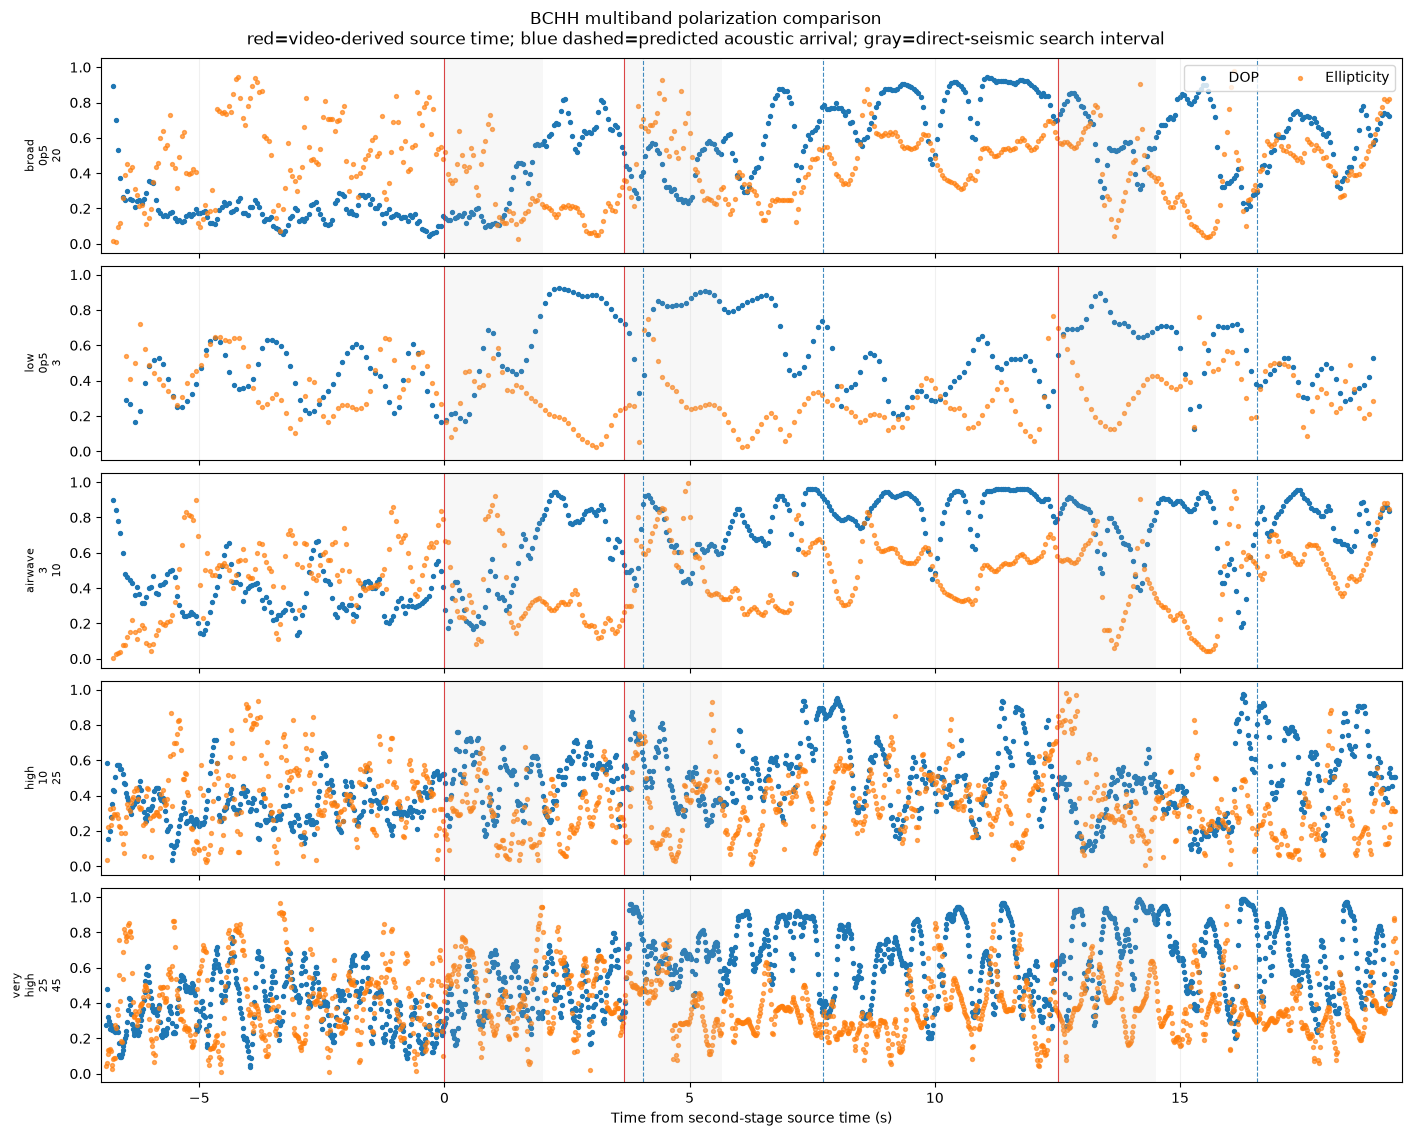

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_multiband_polarization_comparison.png


In [29]:
fig, axes = plt.subplots(
    len(POLARIZATION_BANDS_HZ),
    1,
    figsize=(14, 2.25 * len(POLARIZATION_BANDS_HZ)),
    sharex=True,
    constrained_layout=True,
)

for ax, band_name in zip(np.atleast_1d(axes), POLARIZATION_BANDS_HZ):
    band_df = multiband_polarization.loc[
        multiband_polarization["band"] == band_name
    ]
    ax.scatter(
        band_df["time_from_second_stage_s"],
        band_df["degree_of_polarization"],
        s=8,
        label="DOP",
    )
    ax.scatter(
        band_df["time_from_second_stage_s"],
        band_df["ellipticity"],
        s=8,
        alpha=0.65,
        label="Ellipticity",
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(band_name.replace("_", "\n"), fontsize=8)
    add_event_timing_annotations(ax, include_labels=False)
    ax.grid(True, axis="x", alpha=0.18)

axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("Time from second-stage source time (s)")
axes[-1].set_xlim(
    float(PLOT_START - SECOND_STAGE_SOURCE_TIME),
    float(PLOT_END - SECOND_STAGE_SOURCE_TIME),
)
fig.suptitle(
    "BCHH multiband polarization comparison\n"
    "red=video-derived source time; blue dashed=predicted acoustic arrival; "
    "gray=direct-seismic search interval"
)
fig.savefig(MULTIBAND_COMPARISON_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", MULTIBAND_COMPARISON_FIGURE)


## 11. High-resolution Z/R/T IceWeb spectrograms

`icewebSpectrogram` is used to compute the time-frequency arrays. The custom plotting below keeps all Z/R/T panels on the same event-relative time axis and adds the source/acoustic timing annotations needed for arrival discrimination.

Two FFT windows are generated:

- **0.40 s**: better timing of closely spaced pulses;
- **1.00 s**: better frequency resolution, at the cost of smearing onset time.

Zero padding makes the displayed frequency grid smoother but does not improve the true spectral resolution.


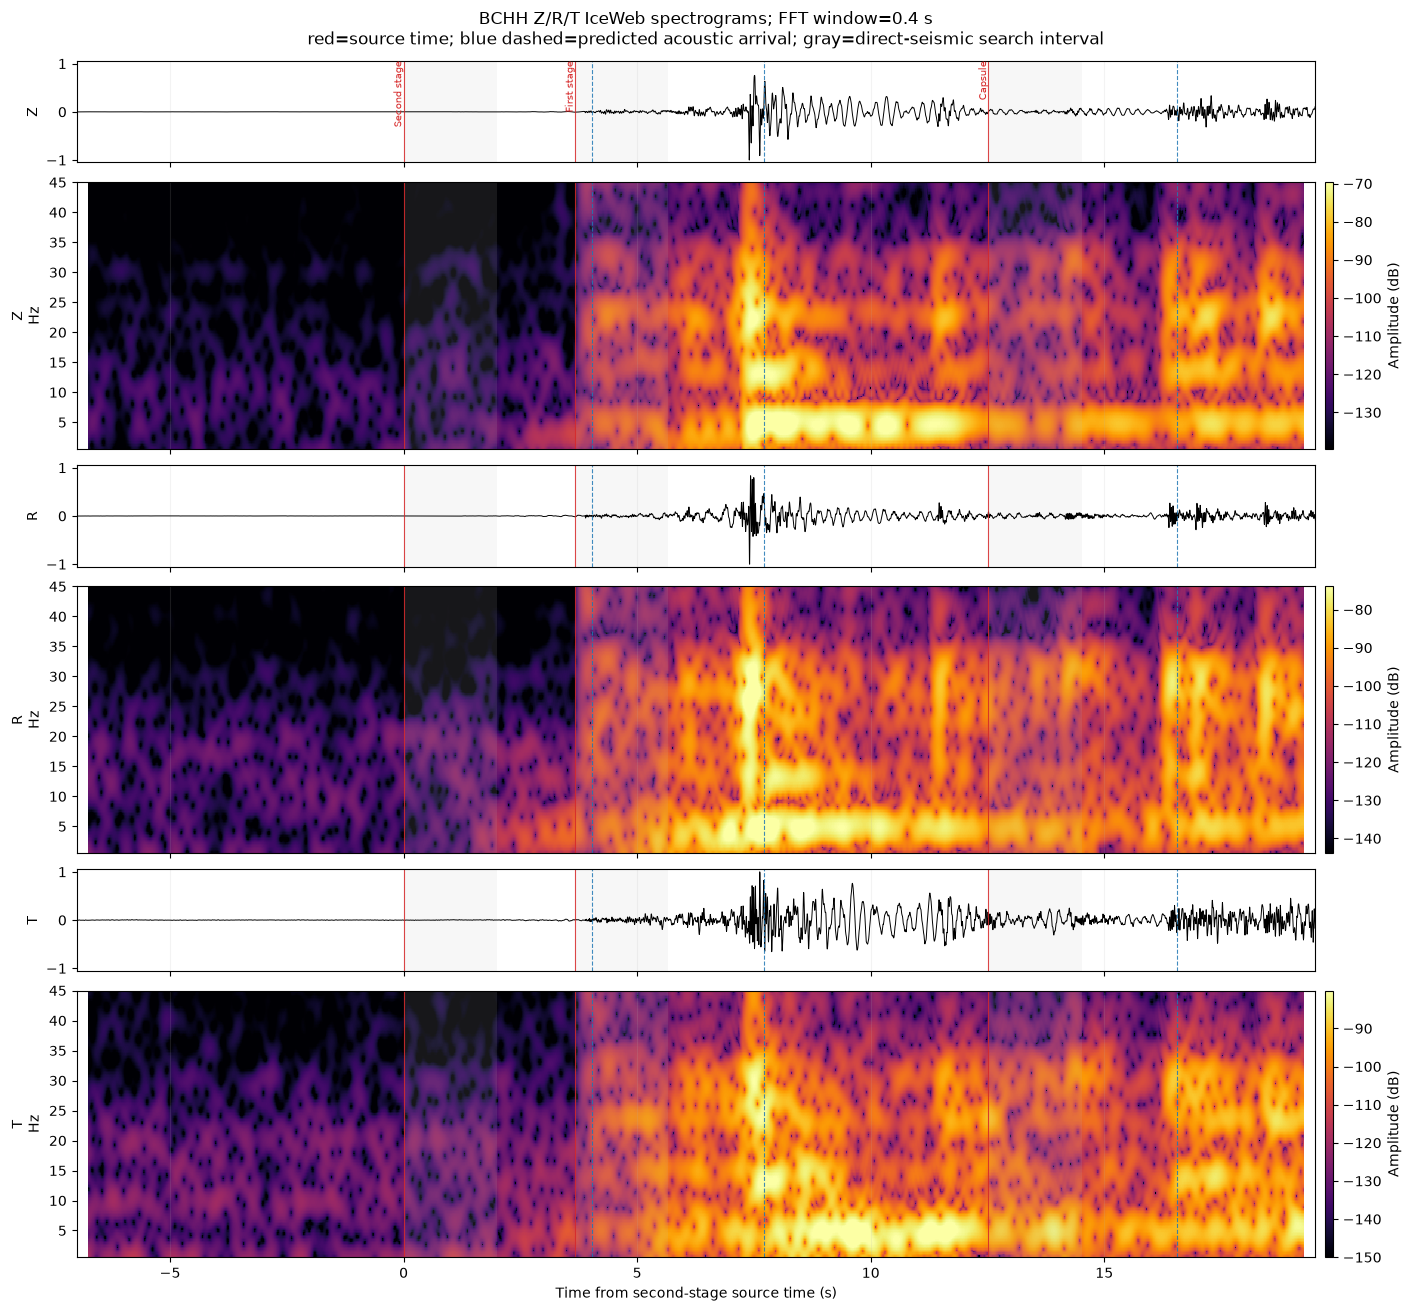

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_iceweb_spectrogram_0p4s.png


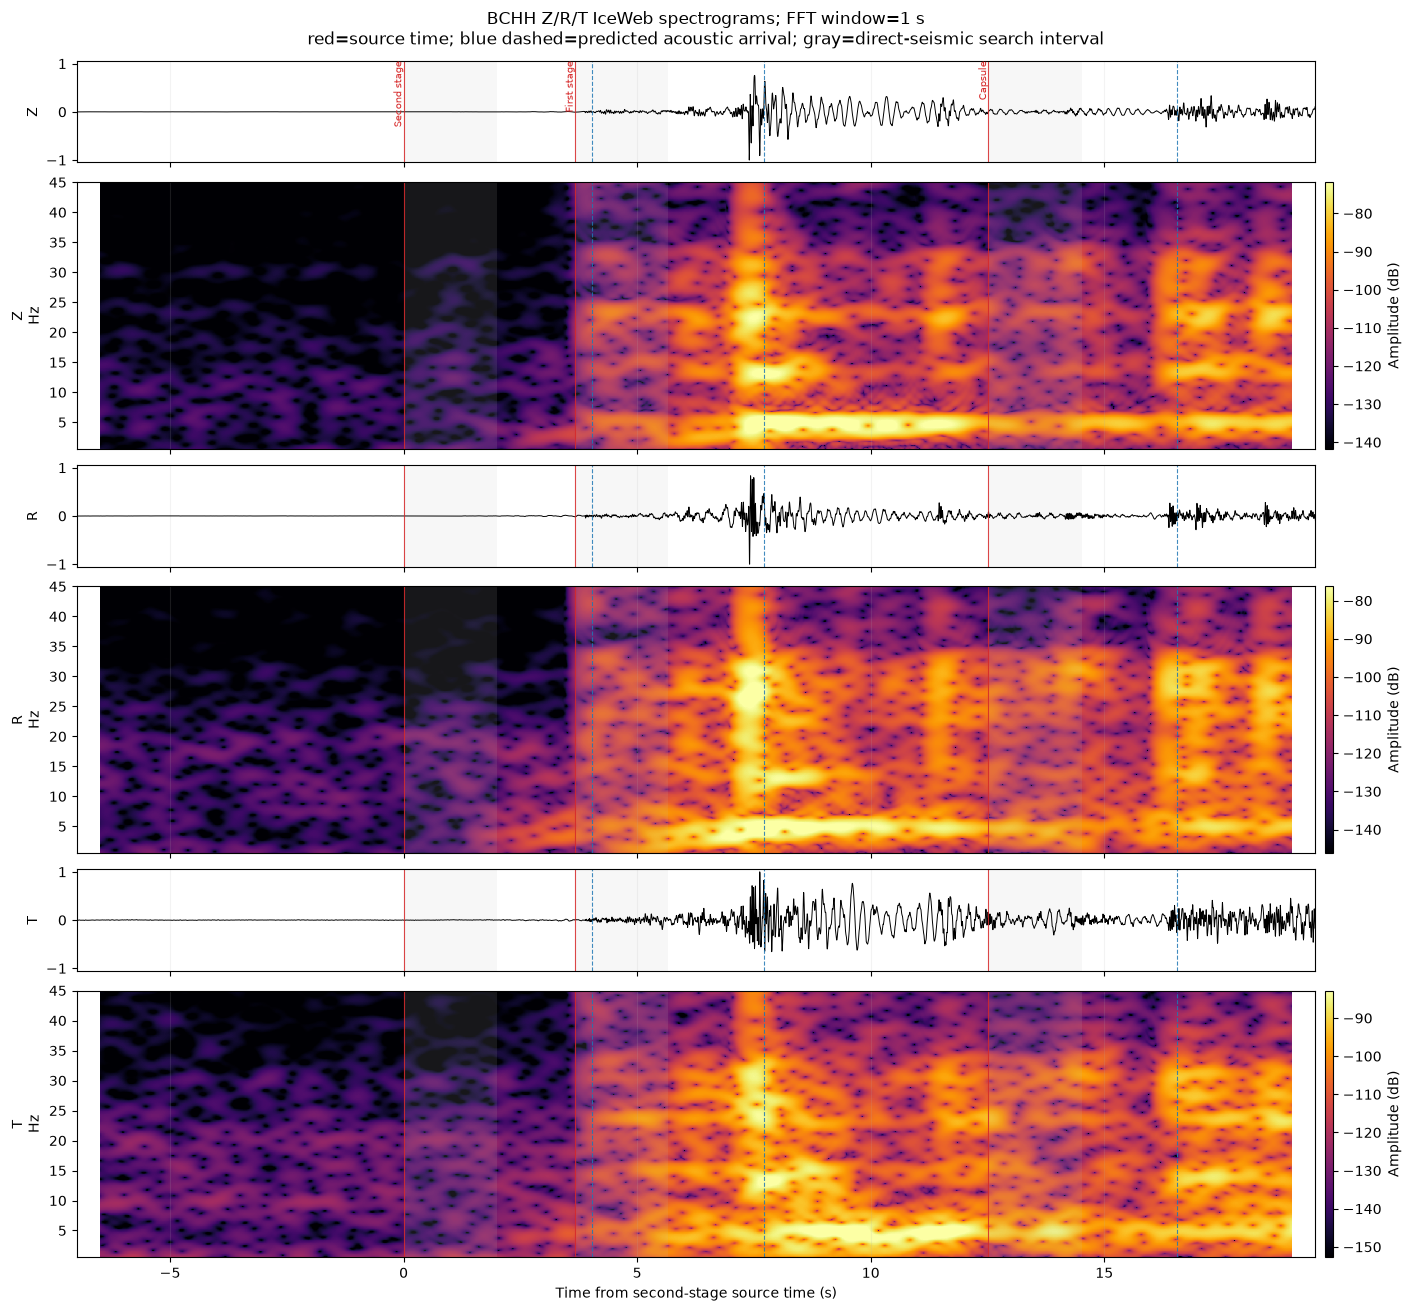

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_zrt_iceweb_spectrogram_1p0s.png


In [30]:
def compute_iceweb_zrt_spectrograms(
    stream_zrt: Stream,
    *,
    secs_per_fft: float,
):
    """Compute IceWeb spectrogram arrays for a focused Z/R/T stream."""
    st_spec = stream_zrt.copy().trim(PLOT_START, PLOT_END, pad=False)
    st_spec.detrend("linear")
    st_spec.detrend("demean")
    iws = icewebSpectrogram(st_spec)
    iws.precompute(secsPerFFT=secs_per_fft)
    return iws


def plot_iceweb_zrt_event_spectrogram(
    iws: icewebSpectrogram,
    *,
    secs_per_fft: float,
    output_path: Path,
) -> None:
    """Plot normalized waveforms and IceWeb amplitude spectrograms for Z/R/T."""
    ordered = Stream([
        unique_component(iws.stream, "Z"),
        unique_component(iws.stream, "R"),
        unique_component(iws.stream, "T"),
    ])
    fig, axes = plt.subplots(
        6,
        1,
        figsize=(14, 13),
        sharex=True,
        gridspec_kw={"height_ratios": [0.55, 1.45] * 3},
        constrained_layout=True,
    )

    meshes = []
    for index, tr in enumerate(ordered):
        wave_ax = axes[2 * index]
        spec_ax = axes[2 * index + 1]
        component = tr.stats.channel[-1]
        relative_wave_time = tr.times(reftime=SECOND_STAGE_SOURCE_TIME)
        wave_ax.plot(relative_wave_time, normalized_data(tr), color="black", lw=0.7)
        wave_ax.set_ylabel(component)
        wave_ax.set_ylim(-1.05, 1.05)

        spec = tr.stats.spectrogramdata
        T = np.asarray(spec["T"], dtype=float)
        F = np.asarray(spec["F"], dtype=float)
        S = np.asarray(spec["S"], dtype=float)
        time_relative = T + float(tr.stats.starttime - SECOND_STAGE_SOURCE_TIME)
        frequency_mask = (F >= SPECTROGRAM_FMIN_HZ) & (F <= SPECTROGRAM_FMAX_HZ)
        F_plot = F[frequency_mask]
        S_plot = S[frequency_mask]
        S_db = 20.0 * np.log10(np.maximum(S_plot, np.finfo(float).tiny))
        vmax = np.nanpercentile(S_db, 99.5)
        vmin = vmax - SPECTROGRAM_DYNAMIC_RANGE_DB
        mesh = spec_ax.pcolormesh(
            time_relative,
            F_plot,
            S_db,
            shading="auto",
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            rasterized=True,
        )
        meshes.append(mesh)
        spec_ax.set_ylabel(f"{component}\nHz")
        spec_ax.set_ylim(SPECTROGRAM_FMIN_HZ, SPECTROGRAM_FMAX_HZ)

        add_event_timing_annotations(wave_ax, include_labels=(index == 0))
        add_event_timing_annotations(spec_ax, include_labels=False)
        wave_ax.grid(True, axis="x", alpha=0.15)
        spec_ax.grid(True, axis="x", alpha=0.15)

    axes[-1].set_xlabel("Time from second-stage source time (s)")
    axes[-1].set_xlim(
        float(PLOT_START - SECOND_STAGE_SOURCE_TIME),
        float(PLOT_END - SECOND_STAGE_SOURCE_TIME),
    )

    # Separate colorbars preserve useful contrast for components with different
    # amplitudes while retaining the same dB dynamic range.
    for index, mesh in enumerate(meshes):
        cbar = fig.colorbar(mesh, ax=axes[2 * index + 1], pad=0.008, aspect=35)
        cbar.set_label("Amplitude (dB)")

    fig.suptitle(
        f"BCHH Z/R/T IceWeb spectrograms; FFT window={secs_per_fft:g} s\n"
        "red=source time; blue dashed=predicted acoustic arrival; "
        "gray=direct-seismic search interval"
    )
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


for secs_per_fft in SPECTROGRAM_FFT_WINDOWS_S:
    iws = compute_iceweb_zrt_spectrograms(st_zrt, secs_per_fft=secs_per_fft)
    fft_tag = str(secs_per_fft).replace(".", "p")
    output_path = config.FIGURE_DIR / f"12_zrt_iceweb_spectrogram_{fft_tag}s.png"
    plot_iceweb_zrt_event_spectrogram(
        iws,
        secs_per_fft=secs_per_fft,
        output_path=output_path,
    )
    SPECTROGRAM_FIGURES.append(output_path)


## 12. Candidate-arrival review table

This table does not automatically declare P or S arrivals. It summarizes polarization statistics in the pre-acoustic search interval after each source event, and in an equally long interval centered on the predicted acoustic arrival. It is intended to identify intervals that merit manual picking in the waveforms and spectrograms.


In [31]:
def summarize_interval(
    frame: pd.DataFrame,
    start_s: float,
    end_s: float,
) -> dict:
    subset = frame.loc[
        (frame["time_from_second_stage_s"] >= start_s)
        & (frame["time_from_second_stage_s"] <= end_s)
    ]
    if subset.empty:
        return {
            "n_windows": 0,
            "maximum_dop": np.nan,
            "median_dop": np.nan,
            "median_ellipticity": np.nan,
            "median_major_inclination_deg": np.nan,
            "median_abs_radial_offset_deg": np.nan,
        }
    radial_offset = np.minimum(
        subset["major_source_relative_azimuth_deg"],
        180.0 - subset["major_source_relative_azimuth_deg"],
    )
    return {
        "n_windows": len(subset),
        "maximum_dop": subset["degree_of_polarization"].max(),
        "median_dop": subset["degree_of_polarization"].median(),
        "median_ellipticity": subset["ellipticity"].median(),
        "median_major_inclination_deg": subset["major_inclination_deg"].median(),
        "median_abs_radial_offset_deg": radial_offset.median(),
    }


review_rows = []
for band_name in POLARIZATION_BANDS_HZ:
    band_df = multiband_polarization.loc[
        multiband_polarization["band"] == band_name
    ]
    for event_label, event_time in SOURCE_EVENTS.items():
        source_relative_s = float(event_time - SECOND_STAGE_SOURCE_TIME)
        intervals = {
            "direct_seismic_search": (
                source_relative_s + DIRECT_SEISMIC_SEARCH_MIN_S,
                source_relative_s + DIRECT_SEISMIC_SEARCH_MAX_S,
            ),
            "predicted_acoustic": (
                source_relative_s + ACOUSTIC_TRAVEL_TIME_S - 0.75,
                source_relative_s + ACOUSTIC_TRAVEL_TIME_S + 0.75,
            ),
        }
        for interval_name, (start_s, end_s) in intervals.items():
            row = {
                "band": band_name,
                "event": event_label,
                "interval": interval_name,
                "start_from_second_stage_s": start_s,
                "end_from_second_stage_s": end_s,
            }
            row.update(summarize_interval(band_df, start_s, end_s))
            review_rows.append(row)

candidate_review = pd.DataFrame(review_rows)
CANDIDATE_REVIEW_CSV = MULTIBAND_OUTPUT_DIR / "12_candidate_arrival_review.csv"
candidate_review.to_csv(CANDIDATE_REVIEW_CSV, index=False)
print("Saved:", CANDIDATE_REVIEW_CSV)
display(candidate_review)


Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/multiband/12_candidate_arrival_review.csv


,band,event,interval,start_from_second_stage_s,end_from_second_stage_s,n_windows,maximum_dop,median_dop,median_ellipticity,median_major_inclination_deg,median_abs_radial_offset_deg
0,broad_0p5_20,Second stage,direct_seismic_search,0.00,2.00,42,0.564264,0.170978,0.277378,66.982633,8.955662
1,broad_0p5_20,Second stage,predicted_acoustic,3.29,4.79,31,0.708881,0.451161,0.518873,27.032348,25.007688
2,broad_0p5_20,First stage,direct_seismic_search,3.67,5.67,41,0.581761,0.425345,0.518873,62.643320,7.853841
3,broad_0p5_20,First stage,predicted_acoustic,6.96,8.46,31,0.864600,0.695309,0.392790,13.358246,9.539490
4,broad_0p5_20,Capsule,direct_seismic_search,12.52,14.52,42,0.856591,0.546158,0.522017,47.461549,23.628072
5,broad_0p5_20,Capsule,predicted_acoustic,15.81,17.31,31,0.733815,0.390486,0.513513,17.527344,23.351193
6,low_0p5_3,Second stage,direct_seismic_search,0.00,2.00,21,0.765449,0.454833,0.363809,83.454919,29.412581
7,low_0p5_3,Second stage,predicted_acoustic,3.29,4.79,16,0.850314,0.786165,0.302122,55.994761,1.105151
8,low_0p5_3,First stage,direct_seismic_search,3.67,5.67,21,0.906887,0.828702,0.264454,73.421746,2.431589
9,low_0p5_3,First stage,predicted_acoustic,6.96,8.46,15,0.738537,0.460175,0.265968,20.662675,53.896421


## 13. Interpretation and figure triage

### Provisional result

Two independent source events show candidate direct seismic arrivals at approximately **1.1 s** after the adopted source time:

- **Second-stage source event:** \(1.1 \pm 0.2\) s.
- **Capsule impact/explosion:** \(1.1 \pm 0.3\) s.

Both candidates are identified from a coordinated change in the Z/R/T waveforms and polarization attributes: increasing radial/vertical motion, increasing rectilinearity or DOP, and decreasing ellipticity before the much stronger ground-coupled acoustic arrival. The capsule result is less clean because it is superimposed on the coda of earlier events. No preferred P pick is adopted for the main explosion because its early interval is strongly contaminated by the preceding event's acoustic arrival.

These remain **candidate P-wave picks**, not definitive phase identifications. A final travel-time or velocity estimate should use source-specific coordinates and explicitly propagate the manual picking uncertainty.

### Suggested paper use

- **Main-text candidate:** the common-scale second-stage zoom, because it shows the clearest transition from background to a weak radial/vertical arrival and then to the dominant airwave-generated motion.
- **Main text or supplement:** the capsule common-scale zoom, because it provides an independent event with a similar approximately 1.1-s delay.
- **Supplement:** independent-scale zooms, broad TwistPy orientation figures, all multiband figures, and both IceWeb spectrogram variants.
- **Diagnostic only unless interpretation improves:** the main-explosion zoom, because overlapping arrivals make the phase association ambiguous.


## 14. Authoritative outputs


In [32]:
authoritative_outputs = {
    "polarization CSV": POLARIZATION_CSV,
    "polarization NPZ": POLARIZATION_NPZ,
    "rotated ZNE Stream": ROTATED_ZNE_PICKLE,
    "rotated ZRT Stream": ROTATED_ZRT_PICKLE,
    "processing summary": SUMMARY_JSON,
    "compact diagnostic figure": DIAGNOSTIC_FIGURE,
    "TwistPy-style ZNE figure": TWISTPY_ZNE_FIGURE,
    "TwistPy-style ZRT figure": TWISTPY_ZRT_FIGURE,
    "multiband polarization table": MULTIBAND_TABLE,
    "multiband comparison figure": MULTIBAND_COMPARISON_FIGURE,
    "candidate arrival review": CANDIDATE_REVIEW_CSV,
    "provisional P-wave picks": PROVISIONAL_P_PICK_TABLE,
}
for label, path in authoritative_outputs.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    print(f"{label}: {path}")

for path in SPECTROGRAM_FIGURES:
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing spectrogram figure: {path}")
    print(f"IceWeb spectrogram figure: {path}")

for label, path in EVENT_FIGURES.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing event figure {label}: {path}")
    print(f"event figure {label}: {path}")


polarization CSV: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.csv
polarization NPZ: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.npz
rotated ZNE Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zne.pkl
rotated ZRT Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zrt.pkl
processing summary: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outp